# Phase 6: Analytical Approach - Analysis v2

This notebook implements the statistical analyses described in the manuscript § 3.5.

## Analyses Included

1. **MCQ Position Bias Analysis (§ 3.5.1)**
   - Visual diagnostics: accuracy by position, deviation from uniform
   - Chi-square test of independence
   - Friedman test (repeated measures)
   - Effect size: Cramér's V

2. **OSQ-Specific Analysis (§ 3.5.2)**
   - Score distributions per model
   - Judge-level distributions
   - Rubric dimension analysis
   - Inter-judge agreement (Spearman correlation)
   - Bootstrap confidence intervals

3. **Format Comparison: MCQ vs OSQ (§ 3.5.3)**
   - MCQ-OSQ scatter plots (multi-judge)
   - Correlation analysis (Pearson, Spearman)
   - Wilcoxon signed-rank test
   - Cohen's d effect size

4. **Tokenomics & Cost-Effectiveness (§ 3.5.4)**
   - Token and cost metrics
   - Cost-quality trade-off visualizations
   - Efficiency analysis

## Dataset

- **MCQ**: 1144 questions total (position variants a/b/c/d)
- **OSQ**: 845 questions (matched subset with MCQ)
- **Matched**: 845 questions for MCQ vs OSQ comparison

---
## 1. SETUP & DATA LOADING

### 1.1 Imports

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import (
    chi2_contingency,          # Chi-square test
    friedmanchisquare,         # Friedman test
    pearsonr, spearmanr,       # Correlations
    wilcoxon,                  # Paired difference test
    bootstrap,                 # Bootstrap CI
    linregress,                # Linear regression
    gaussian_kde               # KDE for distributions
)

# Progress
from tqdm.auto import tqdm
from itertools import combinations

# Token counting
import tiktoken

# Local parsers
import sys
from parsers import (
    parse_mcq_samples, 
    parse_osq_judged_samples, 
    align_mcq_osq_results,
    filter_osq_data, 
    get_available_judges_and_prompts
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Imports complete')

✅ Imports complete


### 1.2 Configuration

In [3]:
# Paths
phase4_dir = Path('../phase4_inference/output')
phase5_dir = Path('../phase5_llm_as_a_judge')
output_dir = Path('output_v2')
output_dir.mkdir(exist_ok=True)

# Constants
N_MCQ_QUESTIONS = 1144  # Total MCQ questions
N_MATCHED_QUESTIONS = 845  # Matched with OSQ
N_BOOTSTRAP = 1000  # Bootstrap iterations
CONFIDENCE_LEVEL = 0.95  # 95% CI

# Position mapping: variants to positions
POSITION_MAPPING = {
    'a': 'A',
    'b': 'B',
    'c': 'C',
    'd': 'D'
}

# Judge selection configuration
# Options: 'all' or list of specific judge names
JUDGE_SELECTION = 'all'

print(f'✅ Configuration complete')
print(f'   Output directory: {output_dir.absolute()}')
print(f'   MCQ questions: {N_MCQ_QUESTIONS}')
print(f'   Matched questions: {N_MATCHED_QUESTIONS}')
print(f'   Bootstrap iterations: {N_BOOTSTRAP}')

✅ Configuration complete
   Output directory: c:\Users\rabel\Desktop\dissertation\src\phase6_analysis\output_v2
   MCQ questions: 1144
   Matched questions: 845
   Bootstrap iterations: 1000


### 1.3 Helper Functions

In [4]:
def export_latex_table(df, filename, caption, label, column_format=None):
    """
    Export DataFrame to LaTeX table with booktabs formatting.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data to export
    filename : str
        Output filename (without path)
    caption : str
        Table caption
    label : str
        LaTeX label for referencing
    column_format : str, optional
        LaTeX column format (e.g., 'lrrr')
    """
    if column_format is None:
        # Auto-generate: 'l' for first column, 'r' for others
        column_format = 'l' + 'r' * (len(df.columns) - 1)
    
    latex_str = df.to_latex(
        index=True,
        column_format=column_format,
        escape=False,
        float_format='%.4f',
        caption=caption,
        label=label
    )
    
    output_path = output_dir / filename
    with open(output_path, 'w') as f:
        f.write(latex_str)
    
    print(f'   ✓ Exported: {filename}')


def identify_complete_judges(osq_df, n_required_questions=845):
    """
    Identify judges that have complete data (all questions for all models).
    A judge is complete if every model has attempted the required number of questions
    (i.e., provided a response or was properly scored, excluding judge/API errors).
    
    Parameters:
    -----------
    osq_df : pd.DataFrame
        OSQ judged samples with parse_status field
    n_required_questions : int
        Number of questions required per model
    
    Returns:
    --------
    list : Judge names with complete data
    """
    complete_judges = []
    
    for judge in osq_df['judge_model'].unique():
        judge_df = osq_df[osq_df['judge_model'] == judge]
        
        # Count samples where model attempted (success or model_error, excluding judge/API errors)
        valid_attempts = judge_df[judge_df['parse_status'].isin(['success', 'model_error'])]
        questions_per_model = valid_attempts.groupby('model')['question_id'].nunique()
        
        if (questions_per_model >= n_required_questions).all():
            complete_judges.append(judge)
    
    return complete_judges


def filter_by_judge_selection(osq_df, judge_selection='all'):
    """
    Filter OSQ data by judge selection.
    
    Parameters:
    -----------
    osq_df : pd.DataFrame
        OSQ judged samples
    judge_selection : str or list
        'all' for all judges, or list of judge names
    
    Returns:
    --------
    pd.DataFrame : Filtered OSQ data
    """
    if judge_selection == 'all':
        return osq_df
    else:
        return osq_df[osq_df['judge_model'].isin(judge_selection)]


print('✅ Helper functions defined')

✅ Helper functions defined


### 1.4 Load Data

#### Load MCQ as mcq_df

In [5]:
print('📂 Loading MCQ samples...')

mcq_df = parse_mcq_samples(phase4_dir, use_latest=True)
mcq_df = pd.DataFrame(mcq_df)
# mcq_df = parse_mcq_samples(phase4_dir)
print(f'   Loaded {len(mcq_df)} MCQ samples')
print(f'   Models: {mcq_df["model"].nunique()}')
print(f'   Questions: {mcq_df["question_id"].nunique()}')
print(f'   Variants: {sorted(mcq_df["variant"].unique())}')

📂 Loading MCQ samples...
📖 Parsing sysengbench/anthropic__claude-sonnet-4.5/samples_sysengbench_2025-11-16T04-31-27.456510.jsonl
📖 Parsing sysengbench/devstral__24b/samples_sysengbench_2025-11-19T22-11-13.670981.jsonl
📖 Parsing sysengbench/gemma3__12b/samples_sysengbench_2025-11-19T22-03-16.047055.jsonl
📖 Parsing sysengbench/gemma3__1b/samples_sysengbench_2025-11-21T00-02-09.310319.jsonl
📖 Parsing sysengbench/gemma3__27b/samples_sysengbench_2025-11-14T23-11-53.059743.jsonl
📖 Parsing sysengbench/gemma3__4b/samples_sysengbench_2025-11-21T00-19-55.392185.jsonl
📖 Parsing sysengbench/google__gemini-2.5-flash/samples_sysengbench_2025-11-16T03-13-38.857265.jsonl
📖 Parsing sysengbench/llama3.2__1b/samples_sysengbench_2025-11-21T01-33-27.866061.jsonl
📖 Parsing sysengbench/llama3.2__3b/samples_sysengbench_2025-11-19T21-42-16.985970.jsonl
📖 Parsing sysengbench/llama3.3__70b/samples_sysengbench_2025-11-15T01-10-38.229116.jsonl
📖 Parsing sysengbench/llama4__16x17b/samples_sysengbench_2025-11-15T01-

#### Load OSQ as osq_df

In [6]:
print('\n📂 Loading OSQ judged samples...')
osq_df = parse_osq_judged_samples(phase5_dir)
osq_df = pd.DataFrame(osq_df)
print(f'   Loaded {len(osq_df)} OSQ samples')
print(f'   Models: {osq_df["model"].nunique()}')
print(f'   Questions: {osq_df["question_id"].nunique()}')
print(f'   Judges: {sorted(osq_df["judge_model"].unique())}')


📂 Loading OSQ judged samples...
📖 Parsing anthropic__claude-sonnet-4.5/samples_sysengbench-osq_2025-11-16T21-02-49.453852__gpt-oss_120b-p1.jsonl (judge: gpt-oss_120b, prompt: p1)
   ⚠️  Line 107: judge error - missing scores ['ta', 'cu', 'co', 'cl', 'pr']
   ⚠️  Line 110: judge error - missing scores ['ta', 'cu', 'co', 'cl', 'pr']
   ⚠️  Line 111: judge error - missing scores ['ta', 'cu', 'co', 'cl', 'pr']
   ⚠️  Line 748: API error - missing_fields: ['student_response']
📖 Parsing anthropic__claude-sonnet-4.5/samples_sysengbench-osq_2025-11-16T21-02-49.453852__openai_gpt-5-mini-p1.jsonl (judge: openai_gpt-5-mini, prompt: p1)
   ⚠️  Line 748: API error - missing_fields: ['student_response']
📖 Parsing anthropic__claude-sonnet-4.5/samples_sysengbench-osq_2025-11-16T21-02-49.453852__openai_gpt-5-p1.jsonl (judge: openai_gpt-5, prompt: p1)
   ⚠️  Line 298: API error - Response ended prematurely
   ⚠️  Line 510: judge error - missing scores ['ta', 'cu', 'co', 'cl', 'pr']
   ⚠️  Line 612: API

#### Checking the OSQ judging progress matrix 

In [7]:
def build_osq_multi_judge_progress_matrix(phase5_dir: Path, use_latest: bool = False) -> pd.DataFrame:
    """
    Build progress matrix showing ALL judge models × ALL evaluated models.
    
    Args:
        phase5_dir: Path to phase5_llm_as_a_judge directory
        use_latest: If True, only show latest judge per model; if False, show all judges
    
    Returns:
        DataFrame with columns: model_name, judge_model, prompt_id, sample_count, judged_file
    """
    import re
    from pathlib import Path
    
    osq_judge_dir = phase5_dir / "sysengbench-osq-llm-judge"
    
    if not osq_judge_dir.exists():
        print(f"⚠️  OSQ judge directory not found: {osq_judge_dir}")
        return pd.DataFrame()
    
    rows = []
    
    # Iterate through each model directory
    model_dirs = sorted([d for d in osq_judge_dir.iterdir() if d.is_dir()])
    
    for model_dir in model_dirs:
        model_name = model_dir.name
        
        # Find all judge files
        judge_files = sorted([f for f in model_dir.iterdir() 
                            if f.is_file() and f.name.startswith('samples_') and f.suffix == '.jsonl'])
        
        if not judge_files:
            continue
        
        # Group by judge model and prompt
        judge_data = []
        for jf in judge_files:
            # Extract judge model and prompt ID from filename
            # Format: samples_sysengbench-osq_TIMESTAMP__JUDGE_MODEL-PROMPT.jsonl
            match = re.search(r'__(.+)-(p\d+)\.jsonl$', jf.name)
            if match:
                judge_model = match.group(1)
                prompt_id = match.group(2)
                
                # Count samples
                try:
                    with open(jf, 'r', encoding='utf-8') as f:
                        sample_count = sum(1 for _ in f)
                except:
                    sample_count = 0
                
                judge_data.append({
                    'file': jf,
                    'judge_model': judge_model,
                    'prompt_id': prompt_id,
                    'sample_count': sample_count,
                    'timestamp': jf.stat().st_mtime
                })
        
        # Filter to latest if requested
        if use_latest and judge_data:
            # Sort by timestamp and take the latest
            judge_data = sorted(judge_data, key=lambda x: x['timestamp'], reverse=True)
            judge_data = [judge_data[0]]
        
        # Add to rows
        for jd in judge_data:
            rows.append({
                'model_name': model_name,
                'judge_model': jd['judge_model'],
                'prompt_id': jd['prompt_id'],
                'sample_count': jd['sample_count'],
                'judged_file': str(jd['file'].name)
            })
    
    df = pd.DataFrame(rows)
    
    if len(df) > 0:
        # Sort for better readability
        df = df.sort_values(['judge_model', 'model_name']).reset_index(drop=True)
    
    return df

print("✓ Multi-judge progress matrix function loaded")

✓ Multi-judge progress matrix function loaded


In [8]:
# Configuration: Judge Loading Strategy
# Set to False to load ALL available judges (recommended for comprehensive analysis)
# Set to True to load only the latest judge per model
OSQ_USE_LATEST = False  # Load ALL judges to see complete judgment matrix

print(f"Judge Loading Mode: {'LATEST ONLY' if OSQ_USE_LATEST else 'ALL JUDGES'}")

Judge Loading Mode: ALL JUDGES


In [9]:
# Build and display OSQ multi-judge progress matrix
print("=" * 80)
print("OSQ MULTI-JUDGE PROGRESS MATRIX")
print("=" * 80)

osq_progress_df = build_osq_multi_judge_progress_matrix(phase5_dir, use_latest=OSQ_USE_LATEST)

if len(osq_progress_df) > 0:
    print(f"\n📊 Found {len(osq_progress_df)} judge-model combinations")
    print(f"   Judges: {osq_progress_df['judge_model'].nunique()}")
    print(f"   Models: {osq_progress_df['model_name'].nunique()}")
    print(f"   Prompts: {osq_progress_df['prompt_id'].unique().tolist()}")
    
    # Display summary by judge
    print("\n📋 Judge Model Summary:")
    judge_summary = osq_progress_df.groupby('judge_model').agg({
        'model_name': 'count',
        'sample_count': 'sum'
    }).rename(columns={'model_name': 'models_judged', 'sample_count': 'total_samples'})
    display(judge_summary)
    
    # Create pivot table for matrix view
    print("\n📊 Progress Matrix (Judge × Model):")
    matrix_pivot = osq_progress_df.pivot_table(
        index='judge_model',
        columns='model_name',
        values='sample_count',
        fill_value=0
    ).astype(int)
    display(matrix_pivot)
    
    # Full detail table
    print("\n📋 Complete Judge-Model Combinations:")
    display(osq_progress_df)
    
else:
    print("⚠️  No OSQ judge data found")

print("\n" + "=" * 80)

OSQ MULTI-JUDGE PROGRESS MATRIX

📊 Found 51 judge-model combinations
   Judges: 3
   Models: 19
   Prompts: ['p1']

📋 Judge Model Summary:


,models_judged,total_samples
judge_model,,
gpt-oss_120b,19,16055
openai_gpt-5,13,8850
openai_gpt-5-mini,19,16055



📊 Progress Matrix (Judge × Model):


model_name,anthropic__claude-sonnet-4.5,devstral__24b,gemma3__12b,gemma3__1b,gemma3__27b,gemma3__4b,google__gemini-2.5-flash,llama3.2__1b,llama3.2__3b,llama3.3__70b,llama4__16x17b,mistral-large__123b,mistral-small3.2__24b,mixtral__8x22b,openai__gpt-4.1,phi3.5__3.8b,phi3__14b,phi4-mini__3.8b,phi4__14b
judge_model,,,,,,,,,,,,,,,,,,,
gpt-oss_120b,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845
openai_gpt-5,845,845,845,845,845,845,845,845,845,845,0,0,0,0,200,0,0,0,200
openai_gpt-5-mini,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845,845



📋 Complete Judge-Model Combinations:


,model_name,judge_model,prompt_id,sample_count,judged_file
0,anthropic__claude-sonnet-4.5,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-16T21-02-49.45...
1,devstral__24b,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-19T22-36-33.28...
2,gemma3__12b,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-19T22-23-32.10...
3,gemma3__1b,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-21T00-11-57.48...
4,gemma3__27b,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-15T01-24-12.25...
5,gemma3__4b,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-21T00-27-28.70...
6,google__gemini-2.5-flash,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-16T04-10-37.21...
7,llama3.2__1b,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-20T23-59-07.91...
8,llama3.2__3b,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-19T21-47-50.05...
9,llama3.3__70b,gpt-oss_120b,p1,845,samples_sysengbench-osq_2025-11-14T23-24-28.91...


#### Filter OSQ to desired judges as osq_filtered

In [10]:
# Optional: Filter OSQ data by specific judge(s) and/or prompt
# FILTER_JUDGE can be a single string or a list of judge names

# Examples:
# FILTER_JUDGE = None                                  # All judges pass through
# FILTER_JUDGE = 'openai_gpt-5'                        # Single judge
# FILTER_JUDGE = ['openai_gpt-5-mini', 'openai_gpt-5'] # Multiple judges
# FILTER_PROMPT = 'p1'                                 # Single prompt

# FILTER_JUDGE = None  # Set to judge name(s) or None for all
FILTER_JUDGE = ['openai_gpt-5-mini', 'gpt-oss_120b'] # Multiple judges
FILTER_PROMPT = None  # Set to prompt ID or None for all

if 'osq_df' in locals() and (FILTER_JUDGE is not None or FILTER_PROMPT is not None):
    print("\n" + "=" * 80)
    print("FILTERING OSQ DATA")
    print("=" * 80)
    
    original_count = len(osq_df)
    
    # Normalize FILTER_JUDGE to a list
    judge_list = [FILTER_JUDGE] if isinstance(FILTER_JUDGE, str) else FILTER_JUDGE
    
    # Apply filters to osq_df
    mask = pd.Series([True] * len(osq_df))
    
    if judge_list is not None:
        mask &= osq_df['judge_model'].isin(judge_list)
    if FILTER_PROMPT is not None:
        mask &= osq_df['prompt_id'] == FILTER_PROMPT
    
    osq_filtered = osq_df[mask].copy()
    
    print(f"\nFiltering criteria:")
    print(f"   Judge(s): {judge_list if judge_list else 'All'}")
    print(f"   Prompt: {FILTER_PROMPT if FILTER_PROMPT else 'All'}")
    print(f"\n✅ OSQ DataFrame filtered: {original_count} → {len(osq_filtered)} samples")
else:
    osq_filtered = osq_df.copy() if 'osq_df' in locals() else None
    print("\n📌 No filtering applied. Using all OSQ data.")


FILTERING OSQ DATA

Filtering criteria:
   Judge(s): ['openai_gpt-5-mini', 'gpt-oss_120b']
   Prompt: All

✅ OSQ DataFrame filtered: 40960 → 32110 samples


In [11]:
osq_filtered

,model,question_id,category,tags,osq_prompt,expected_answer,model_response,blooms_level,judge_model,prompt_id,...,completeness,clarity_organization,professional_relevance,total_score,percentage,is_correct,parse_status,has_response,sample_id,file
0,anthropic__claude-sonnet-4.5,1,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,"Define ""uncertainty"" in systems engineering. A...",A condition in which system outcomes or behavi...,[Uncertainty in systems engineering refers to ...,Remember,gpt-oss_120b,p1,...,20.0,18.0,18.0,93.0,93.0,True,success,True,0,samples_sysengbench-osq_2025-11-16T21-02-49.45...
1,anthropic__claude-sonnet-4.5,2,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,"In systems engineering, define ""risk"" precisel...",Risk is the potential for loss or an undesirab...,"[In systems engineering, risk represents the p...",Remember,gpt-oss_120b,p1,...,20.0,20.0,19.0,98.0,98.0,True,success,True,1,samples_sysengbench-osq_2025-11-16T21-02-49.45...
2,anthropic__claude-sonnet-4.5,3,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,"In systems engineering, identify the two main ...",Epistemic uncertainty: reducible uncertainty d...,[The two main types of uncertainty in systems ...,Remember,gpt-oss_120b,p1,...,20.0,20.0,19.0,98.0,98.0,True,success,True,2,samples_sysengbench-osq_2025-11-16T21-02-49.45...
3,anthropic__claude-sonnet-4.5,4,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,"In systems engineering, what is the primary go...",To ensure that all system components function ...,[The primary goal of systems integration is to...,Remember,gpt-oss_120b,p1,...,19.0,19.0,17.0,93.0,93.0,True,success,True,3,samples_sysengbench-osq_2025-11-16T21-02-49.45...
4,anthropic__claude-sonnet-4.5,5,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,"In systems engineering, define ""reliability."" ...",The ability to perform required functions unde...,[Reliability is the probability that a system ...,Remember,gpt-oss_120b,p1,...,20.0,18.0,18.0,95.0,95.0,True,success,True,4,samples_sysengbench-osq_2025-11-16T21-02-49.45...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40755,phi4__14b,1140,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,"In MIL-STD-461, which specific test assesses e...",RE102,[The specific test in MIL-STD-461 that assesse...,Remember,openai_gpt-5-mini,p1,...,3.0,14.0,6.0,31.0,31.0,False,success,True,840,samples_sysengbench-osq_2025-11-14T23-10-44.86...
40756,phi4__14b,1141,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,"In MIL-STD-461, which specific test evaluates ...",RE103,[The specific test in MIL-STD-461 that evaluat...,Remember,openai_gpt-5-mini,p1,...,5.0,16.0,8.0,39.0,39.0,False,success,True,841,samples_sysengbench-osq_2025-11-14T23-10-44.86...
40757,phi4__14b,1142,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,"In MIL-STD-461, which specific test evaluates ...",RS101,[The specific test in MIL-STD-461 that evaluat...,Remember,openai_gpt-5-mini,p1,...,10.0,16.0,12.0,67.0,67.0,False,success,True,842,samples_sysengbench-osq_2025-11-14T23-10-44.86...
40758,phi4__14b,1143,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,"In MIL-STD-461, which test evaluates equipment...",RS103,[The test in MIL-STD-461 that evaluates equipm...,Remember,openai_gpt-5-mini,p1,...,12.0,18.0,15.0,74.0,74.0,True,success,True,843,samples_sysengbench-osq_2025-11-14T23-10-44.86...


#### Create the aligned_df (mcq_df + osq_filtered)
`osq_filtered` is sometimes simply the same as osq_df if we did not filter out any judges.

In [12]:
# Use existing osq_filtered data
print("=" * 80)
print("OSQ DATA SUMMARY")
print("=" * 80)

if 'osq_filtered' in locals() and osq_filtered is not None and len(osq_filtered) > 0:
    print(f"\n✅ Using osq_filtered DataFrame: {osq_filtered.shape}")
    print(f"   Models: {osq_filtered['model'].unique().tolist()}")
    print(f"   Questions: {osq_filtered['question_id'].nunique()}")
    print(f"   Mean score: {osq_filtered['total_score'].mean():.2f}")
    
    # Count samples by judge and prompt
    print("\n📊 Sample counts by judge and prompt:")
    judge_prompt_counts = osq_filtered.groupby(['judge_model', 'prompt_id']).size().reset_index(name='count')
    for _, row in judge_prompt_counts.iterrows():
        print(f"   {row['judge_model']:30s} | {row['prompt_id']:5s} | {row['count']:4d} samples")
    
    # Align MCQ and OSQ data
    print("\n📊 Aligning MCQ and OSQ data...")
    aligned_df = pd.DataFrame(align_mcq_osq_results(mcq_df, osq_filtered.to_dict('records')))
    print(f"✅ Aligned DataFrame shape: {aligned_df.shape}")
    
    osq_available = True
else:
    print("⚠️  No OSQ filtered data available. OSQ plots will be skipped.")
    osq_available = False
    aligned_df = pd.DataFrame()

OSQ DATA SUMMARY

✅ Using osq_filtered DataFrame: (32110, 22)
   Models: ['anthropic__claude-sonnet-4.5', 'devstral__24b', 'gemma3__12b', 'gemma3__1b', 'gemma3__27b', 'gemma3__4b', 'google__gemini-2.5-flash', 'llama3.2__1b', 'llama3.2__3b', 'llama3.3__70b', 'llama4__16x17b', 'mistral-large__123b', 'mistral-small3.2__24b', 'mixtral__8x22b', 'openai__gpt-4.1', 'phi3.5__3.8b', 'phi3__14b', 'phi4-mini__3.8b', 'phi4__14b']
   Questions: 845
   Mean score: 76.30

📊 Sample counts by judge and prompt:
   gpt-oss_120b                   | p1    | 16055 samples
   openai_gpt-5-mini              | p1    | 16055 samples

📊 Aligning MCQ and OSQ data...
✅ Aligned 43472 records across 2 judge(s) (strategy: drop)
✅ Aligned DataFrame shape: (43472, 24)


In [13]:
# Use existing osq_filtered data
print("=" * 80)
print("OSQ DATA SUMMARY & ALIGNMENT")
print("=" * 80)

if 'osq_filtered' in locals() and osq_filtered is not None and len(osq_filtered) > 0:
    # Input summary
    print(f"\n📂 INPUT: osq_filtered")
    print(f"   Total samples: {len(osq_filtered):,}")
    print(f"   Unique models: {osq_filtered['model'].nunique()}")
    print(f"   Unique questions: {osq_filtered['question_id'].nunique()}")
    print(f"   Judges: {osq_filtered['judge_model'].nunique()}")
    print(f"   Models: {osq_filtered['model'].unique().tolist()}")
    
    # Sample counts by judge
    print("\n📊 Samples per judge:")
    for judge, count in osq_filtered.groupby('judge_model').size().items():
        print(f"   {judge:30s}: {count:,} samples")
    
    # Alignment
    print("\n" + "-" * 40)
    print("🔗 ALIGNING MCQ + OSQ...")
    print(f"   MCQ input: {len(mcq_df):,} samples ({mcq_df['question_id'].nunique()} questions)")
    print(f"   OSQ input: {len(osq_filtered):,} samples ({osq_filtered['question_id'].nunique()} questions)")
    
    aligned_df = pd.DataFrame(align_mcq_osq_results(mcq_df, osq_filtered.to_dict('records')))
    
    print(f"\n✅ OUTPUT: aligned_df")
    print(f"   Total aligned samples: {len(aligned_df):,}")
    if len(aligned_df) > 0:
        print(f"   Unique models: {aligned_df['model'].nunique()}")
        print(f"   Unique questions: {aligned_df['question_id'].nunique()}")
    
    osq_available = True
else:
    print("\n⚠️  No OSQ filtered data available. OSQ analyses will be skipped.")
    osq_available = False
    aligned_df = pd.DataFrame()

print("\n" + "=" * 80)

OSQ DATA SUMMARY & ALIGNMENT

📂 INPUT: osq_filtered
   Total samples: 32,110
   Unique models: 19
   Unique questions: 845
   Judges: 2
   Models: ['anthropic__claude-sonnet-4.5', 'devstral__24b', 'gemma3__12b', 'gemma3__1b', 'gemma3__27b', 'gemma3__4b', 'google__gemini-2.5-flash', 'llama3.2__1b', 'llama3.2__3b', 'llama3.3__70b', 'llama4__16x17b', 'mistral-large__123b', 'mistral-small3.2__24b', 'mixtral__8x22b', 'openai__gpt-4.1', 'phi3.5__3.8b', 'phi3__14b', 'phi4-mini__3.8b', 'phi4__14b']

📊 Samples per judge:
   gpt-oss_120b                  : 16,055 samples
   openai_gpt-5-mini             : 16,055 samples

----------------------------------------
🔗 ALIGNING MCQ + OSQ...
   MCQ input: 108,680 samples (1144 questions)
   OSQ input: 32,110 samples (845 questions)
✅ Aligned 43472 records across 2 judge(s) (strategy: drop)

✅ OUTPUT: aligned_df
   Total aligned samples: 43,472
   Unique models: 19
   Unique questions: 1144



In [14]:
aligned_df

,model,question_id,category,tags,question,mcq_random_correct,mcq_a_correct,mcq_b_correct,mcq_c_correct,mcq_d_correct,...,osq_technical_accuracy,osq_conceptual_understanding,osq_completeness,osq_clarity_organization,osq_professional_relevance,blooms_level,judge_model,prompt_id,parse_status,has_response
0,anthropic__claude-sonnet-4.5,1,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What best describes the concept of uncertainty...,True,True,True,True,True,...,18.0,19.0,20.0,18.0,18.0,Remember,gpt-oss_120b,p1,success,True
1,anthropic__claude-sonnet-4.5,1,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What best describes the concept of uncertainty...,True,True,True,True,True,...,20.0,20.0,20.0,20.0,20.0,Remember,openai_gpt-5-mini,p1,success,True
2,anthropic__claude-sonnet-4.5,2,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,How is risk defined in systems engineering?,True,True,True,True,True,...,20.0,19.0,20.0,20.0,19.0,Remember,gpt-oss_120b,p1,success,True
3,anthropic__claude-sonnet-4.5,2,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,How is risk defined in systems engineering?,True,True,True,True,True,...,20.0,20.0,20.0,20.0,20.0,Remember,openai_gpt-5-mini,p1,success,True
4,anthropic__claude-sonnet-4.5,3,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,Which of the following best describes the two ...,True,True,True,True,True,...,20.0,19.0,20.0,20.0,19.0,Remember,gpt-oss_120b,p1,success,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43467,phi4__14b,1142,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,Which test within MIL-STD-461 evaluates equipm...,True,False,True,False,True,...,14.0,15.0,10.0,16.0,12.0,Remember,openai_gpt-5-mini,p1,success,True
43468,phi4__14b,1143,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,Which test within MIL-STD-461 evaluates equipm...,False,False,True,True,True,...,5.0,15.0,8.0,18.0,14.0,Remember,gpt-oss_120b,p1,success,True
43469,phi4__14b,1143,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,Which test within MIL-STD-461 evaluates equipm...,False,False,True,True,True,...,12.0,17.0,12.0,18.0,15.0,Remember,openai_gpt-5-mini,p1,success,True
43470,phi4__14b,1144,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,Which test within MIL-STD-461 evaluates equipm...,False,False,True,False,False,...,4.0,12.0,6.0,18.0,12.0,Remember,gpt-oss_120b,p1,success,True


#### Understanding `aligned_df`

The `aligned_df` DataFrame **aligns MCQ and OSQ data by (model, question_id, judge_model)**. It contains:

- **All MCQ questions**: Every question from `mcq_df`, with OSQ scores added where available
- **One row per (model, question_id, judge_model)**: Each row represents a single model's response to a single question, for each judge
- **MCQ results across all position variants**: `mcq_a_correct`, `mcq_b_correct`, `mcq_c_correct`, `mcq_d_correct`, plus `mcq_avg_correct`
- **OSQ rubric scores**: `osq_total_score`, `osq_percentage`, and individual dimension scores (may be `None` if no OSQ match)
- **Metadata**: `category`, `tags`, `blooms_level`, `parse_status`

**Key columns:**
| Column | Description |
|--------|-------------|
| `model` | Model under evaluation |
| `question_id` | Unique question identifier |
| `judge_model` | LLM judge that scored the OSQ response |
| `mcq_avg_correct` | Average correctness across position variants (0-1) |
| `osq_total_score` | Total OSQ score (0-100), or `None` if no OSQ data |
| `osq_percentage` | OSQ score as percentage |
| `parse_status` | `success`, `model_error`, `judge_error`, `api_error`, or `None` |

⚠️ **Note**: For MCQ vs OSQ comparison analyses, you must **filter to the intersection** — rows where both MCQ and OSQ data exist (i.e., `osq_total_score.notna()`). This ensures fair comparison on the same question set.

#### aligned_df_intersection (OSQ mapped to equivalent MCQ)

In [15]:
# Create aligned_df_intersection for MCQ vs OSQ comparison analysis
print("=" * 80)
print("CREATING ALIGNED INTERSECTION FOR MCQ vs OSQ COMPARISON")
print("=" * 80)

# Filter to rows where both MCQ and OSQ data exist
aligned_df_intersection = aligned_df[
    (aligned_df['mcq_avg_correct'].notna()) & 
    (aligned_df['osq_total_score'].notna())
].copy()

print(f"\n📂 INPUT: aligned_df")
print(f"   Total rows: {len(aligned_df):,}")
print(f"   Unique questions: {aligned_df['question_id'].nunique()}")

print(f"\n✅ OUTPUT: aligned_df_intersection")
print(f"   Total rows: {len(aligned_df_intersection):,}")
print(f"   Unique models: {aligned_df_intersection['model'].nunique()}")
print(f"   Unique questions: {aligned_df_intersection['question_id'].nunique()}")
print(f"   Unique judges: {aligned_df_intersection['judge_model'].nunique()}")

# Show breakdown
print(f"\n📊 Rows per judge:")
for judge, count in aligned_df_intersection.groupby('judge_model').size().items():
    print(f"   {judge:30s}: {count:,} rows")

# Calculate how much was dropped
dropped = len(aligned_df) - len(aligned_df_intersection)
drop_pct = (dropped / len(aligned_df)) * 100 if len(aligned_df) > 0 else 0
print(f"\n📉 Dropped {dropped:,} rows ({drop_pct:.1f}%) missing MCQ or OSQ data")

print("\n" + "=" * 80)

CREATING ALIGNED INTERSECTION FOR MCQ vs OSQ COMPARISON

📂 INPUT: aligned_df
   Total rows: 43,472
   Unique questions: 1144

✅ OUTPUT: aligned_df_intersection
   Total rows: 32,105
   Unique models: 19
   Unique questions: 845
   Unique judges: 2

📊 Rows per judge:
   gpt-oss_120b                  : 16,051 rows
   openai_gpt-5-mini             : 16,054 rows

📉 Dropped 11,367 rows (26.1%) missing MCQ or OSQ data



### 1.5 Data Summary

#### Parse Status Attribution

The OSQ parser now retains ALL samples and tracks their `parse_status`:

- **`success`**: Judge successfully extracted all 5 scores from model response → normal scoring
- **`model_error`**: Model provided empty/whitespace-only response → assign `total_score=0`, `is_correct=False`
- **`judge_error`**: Model provided non-empty response but judge failed to extract scores → assign `total_score=None` (exclude from metrics)
- **`api_error`**: Judge API failure (timeout, connection reset, etc.) → assign `total_score=None` (exclude from metrics)

**Rationale**: Any non-empty response deserves grading. If the model tried but failed (empty response), it receives 0 points. If the model submitted a response but the judge malfunctioned, we exclude that sample to avoid penalizing the model unfairly.

For the two sections below:

| Section   | Actually means                                           |
| ------ | -------------------------------------------------------- |
| Raw OSQ parsing diagnostics | *“How healthy was the entire OSQ run?”*                  |
| Parsing diagnostics | *“How clean is the OSQ data we are willing to analyze?”* |


#### OSQ Parse Status (All Judges, Pre-Filtering)

This section is answering:

“Across all OSQ runs, what went wrong and where?”

In [16]:
# Get unique models (intersection of MCQ and OSQ)
mcq_models = set(mcq_df['model'].unique())
osq_models = set(osq_filtered['model'].unique())
common_models = sorted(list(mcq_models & osq_models))

# Parse status breakdown
if 'parse_status' in osq_df.columns:
    status_counts = osq_df['parse_status'].value_counts()
    status_breakdown = f"\nOSQ Parse Status Breakdown:\n"
    for status, count in status_counts.items():
        pct = (count / len(osq_df)) * 100
        status_breakdown += f"  {status}: {count:,} ({pct:.1f}%)\n"
    print(status_breakdown)
    
    # Error breakdown by model (columns = models, rows = error types)
    error_statuses = ['judge_error', 'api_error', 'model_error']
    error_df = osq_df[osq_df['parse_status'].isin(error_statuses)]
    
    if len(error_df) > 0:
        print('\n' + '='*80)
        print('OSQ PARSE ERRORS BY MODEL UNDER EVALUATION')
        print('='*80)
        
        error_pivot = pd.crosstab(
            error_df['parse_status'], 
            error_df['model'],
            margins=True, 
            margins_name='Total'
        )
        
        row_order = [s for s in error_statuses if s in error_pivot.index] + ['Total']
        error_pivot = error_pivot.reindex(row_order)
        print(error_pivot.to_string())
        print()
        
        print('\n' + '='*80)
        print('OSQ PARSE ERRORS BY JUDGE MODEL')
        print('='*80)
        
        judge_error_pivot = pd.crosstab(
            error_df['parse_status'],
            error_df['judge_model'],
            margins=True,
            margins_name='Total'
        )
        judge_error_pivot = judge_error_pivot.reindex(row_order)
        print(judge_error_pivot.to_string())
        print()

# Calculate matched question IDs (intersection of MCQ and OSQ questions)
mcq_question_ids = set(mcq_df['question_id'].unique())
osq_question_ids = set(osq_filtered['question_id'].unique())
matched_question_ids = mcq_question_ids & osq_question_ids

# Identify complete judges if not already defined
if 'COMPLETE_JUDGES' not in locals():
    COMPLETE_JUDGES = identify_complete_judges(osq_filtered, n_required_questions=len(matched_question_ids))

summary_data = {
    'Metric': [
        'Total MCQ samples',
        'Total OSQ samples',
        'OSQ filtered (by judge)',
        'OSQ success samples',
        'OSQ model_error samples',
        'OSQ judge_error samples',
        'OSQ api_error samples',
        'Unique MCQ questions',
        'Unique OSQ questions',
        'Matched questions',
        'MCQ models',
        'OSQ models',
        'Common models',
        'Complete judges',
        'Position variants'
    ],
    'Count': [
        len(mcq_df),
        len(osq_df),
        len(osq_filtered),
        len(osq_df[osq_df['parse_status'] == 'success']) if 'parse_status' in osq_df.columns else 0,
        len(osq_df[osq_df['parse_status'] == 'model_error']) if 'parse_status' in osq_df.columns else 0,
        len(osq_df[osq_df['parse_status'] == 'judge_error']) if 'parse_status' in osq_df.columns else 0,
        len(osq_df[osq_df['parse_status'] == 'api_error']) if 'parse_status' in osq_df.columns else 0,
        mcq_df['question_id'].nunique(),
        osq_df['question_id'].nunique(),
        len(matched_question_ids),
        len(mcq_models),
        len(osq_models),
        len(common_models),
        len(COMPLETE_JUDGES),
        len(POSITION_MAPPING)
    ]
}

summary_df = pd.DataFrame(summary_data)
print('\n' + '='*60)
print('DATA SUMMARY')
print('='*60)
print(summary_df.to_string(index=False))
print('='*60)


OSQ Parse Status Breakdown:
  success: 40,933 (99.9%)
  api_error: 19 (0.0%)
  judge_error: 8 (0.0%)


OSQ PARSE ERRORS BY MODEL UNDER EVALUATION
model         anthropic__claude-sonnet-4.5  devstral__24b  gemma3__1b  gemma3__27b  gemma3__4b  google__gemini-2.5-flash  llama3.2__1b  llama3.2__3b  llama3.3__70b  Total
parse_status                                                                                                                                                              
judge_error                              4              0           1            0           0                         2             1             0              0      8
api_error                                6              3           0            2           1                         1             0             5              1     19
Total                                   10              3           1            2           1                         3             1             5              1     2

#### OSQ Parse Status (Filtered Judges, Analysis Set)

Parse stats are recomputed on a smaller universe

Now the parse breakdown is recomputed on osq_filtered, not osq_df:

In [17]:
# =============================================================================
# 1. MCQ DATA SUMMARY
# =============================================================================
print("=" * 80)
print("1. MCQ DATA SUMMARY")
print("=" * 80)

print(f"\n📂 Source: mcq_df")
print(f"   Total samples: {len(mcq_df):,}")
print(f"   Unique models: {mcq_df['model'].nunique()}")
print(f"   Unique questions: {mcq_df['question_id'].nunique()}")
print(f"   Variants: {sorted(mcq_df['variant'].unique())}")

# Samples per variant
print(f"\n📊 Samples per variant:")
for variant, count in mcq_df.groupby('variant').size().items():
    print(f"   {variant}: {count:,}")

# Models list
print(f"\n📋 Models: {sorted(mcq_df['model'].unique())}")

# =============================================================================
# 2. OSQ DATA SUMMARY
# =============================================================================
print("\n" + "=" * 80)
print("2. OSQ DATA SUMMARY")
print("=" * 80)

print(f"\n📂 Source: osq_df (full) → osq_filtered (after judge filter)")
print(f"   osq_df total: {len(osq_df):,}")
print(f"   osq_filtered total: {len(osq_filtered):,}")
print(f"   Unique models: {osq_filtered['model'].nunique()}")
print(f"   Unique questions: {osq_filtered['question_id'].nunique()}")
print(f"   Unique judges: {osq_filtered['judge_model'].nunique()}")

# Parse status breakdown
if 'parse_status' in osq_filtered.columns:
    print(f"\n📋 Parse Status Breakdown:")
    status_counts = osq_filtered['parse_status'].value_counts()
    for status, count in status_counts.items():
        pct = (count / len(osq_filtered)) * 100
        print(f"   {status:15s}: {count:,} ({pct:.1f}%)")
    
    # Error breakdown by model
    error_statuses = ['judge_error', 'api_error', 'model_error']
    error_df = osq_filtered[osq_filtered['parse_status'].isin(error_statuses)]
    
    if len(error_df) > 0:
        print('\n' + '-'*60)
        print('OSQ PARSE ERRORS BY MODEL')
        print('-'*60)
        error_pivot = pd.crosstab(
            error_df['parse_status'], 
            error_df['model'],
            margins=True, 
            margins_name='Total'
        )
        row_order = [s for s in error_statuses if s in error_pivot.index] + ['Total']
        error_pivot = error_pivot.reindex(row_order)
        print(error_pivot.to_string())
        
        print('\n' + '-'*60)
        print('OSQ PARSE ERRORS BY JUDGE')
        print('-'*60)
        judge_error_pivot = pd.crosstab(
            error_df['parse_status'],
            error_df['judge_model'],
            margins=True,
            margins_name='Total'
        )
        judge_error_pivot = judge_error_pivot.reindex(row_order)
        print(judge_error_pivot.to_string())

# Judges list
print(f"\n📋 Judges: {sorted(osq_filtered['judge_model'].unique())}")

# =============================================================================
# 3. ALIGNMENT SUMMARY (MCQ vs OSQ Comparison)
# =============================================================================
print("\n" + "=" * 80)
print("3. ALIGNMENT SUMMARY (MCQ vs OSQ)")
print("=" * 80)

print(f"\n📂 aligned_df (full alignment)")
print(f"   Total rows: {len(aligned_df):,}")
print(f"   Unique models: {aligned_df['model'].nunique()}")
print(f"   Unique questions: {aligned_df['question_id'].nunique()}")
print(f"   Unique judges: {aligned_df['judge_model'].nunique()}")

# How many have MCQ only, OSQ only, or both
mcq_only = aligned_df['osq_total_score'].isna().sum()
has_both = aligned_df['osq_total_score'].notna().sum()
print(f"\n📊 Coverage:")
print(f"   Rows with OSQ data: {has_both:,}")
print(f"   Rows without OSQ (MCQ-only): {mcq_only:,}")

print(f"\n📂 aligned_df_intersection (MCQ+OSQ matched)")
print(f"   Total rows: {len(aligned_df_intersection):,}")
print(f"   Unique models: {aligned_df_intersection['model'].nunique()}")
print(f"   Unique questions: {aligned_df_intersection['question_id'].nunique()}")
print(f"   Unique judges: {aligned_df_intersection['judge_model'].nunique()}")

# Set COMPLETE_JUDGES for downstream analysis
COMPLETE_JUDGES = sorted(aligned_df_intersection['judge_model'].unique())
print(f"\n📋 Judges for comparison analysis: {COMPLETE_JUDGES}")

# Samples per judge in intersection
print(f"\n📊 Intersection samples per judge:")
for judge, count in aligned_df_intersection.groupby('judge_model').size().items():
    print(f"   {judge:30s}: {count:,}")

print("\n" + "=" * 80)
print("✅ Data ready for analysis")
print("=" * 80)

1. MCQ DATA SUMMARY

📂 Source: mcq_df
   Total samples: 108,680
   Unique models: 19
   Unique questions: 1144
   Variants: ['a', 'b', 'c', 'd', 'random']

📊 Samples per variant:
   a: 21,736
   b: 21,736
   c: 21,736
   d: 21,736
   random: 21,736

📋 Models: ['anthropic__claude-sonnet-4.5', 'devstral__24b', 'gemma3__12b', 'gemma3__1b', 'gemma3__27b', 'gemma3__4b', 'google__gemini-2.5-flash', 'llama3.2__1b', 'llama3.2__3b', 'llama3.3__70b', 'llama4__16x17b', 'mistral-large__123b', 'mistral-small3.2__24b', 'mixtral__8x22b', 'openai__gpt-4.1', 'phi3.5__3.8b', 'phi3__14b', 'phi4-mini__3.8b', 'phi4__14b']

2. OSQ DATA SUMMARY

📂 Source: osq_df (full) → osq_filtered (after judge filter)
   osq_df total: 40,960
   osq_filtered total: 32,110
   Unique models: 19
   Unique questions: 845
   Unique judges: 2

📋 Parse Status Breakdown:
   success        : 32,105 (100.0%)
   judge_error    : 3 (0.0%)
   api_error      : 2 (0.0%)

------------------------------------------------------------
OSQ PA

#### Dataframes passed on for Analyses in Section 2, 3, and 4.

Data ready for analysis:
- MCQ Position Bias: use `mcq_df` or `aligned_df` with filtering to drop non-relevant OSQ columns
- OSQ Analysis: use `osq_filtered` or `aligned_df` or `aligned_df_intersection`, with filtering i fusing the latter two to drop non-relevant MCQ columns
- MCQ vs OSQ Comparison: use `aligned_df_intersection`

The following analyses will use:
- MCQ Position Bias: use `mcq_df`
  - This allows us to use ALL of the MCQs, and not just the ones that align to OSQ. It also means we do not have to filter.
- OSQ Analysis: use `osq_filtered` or `aligned_df` or `aligned_df_intersection`, with filtering on latter two to drop non-relevant MCQ columns
  - Using `aligned_df_intersection` for commonality with next section.
- MCQ vs OSQ Comparison: use `aligned_df_intersection`
  - The only dataset that has the 1:1 MCQ vs OSQ.
- Cost Analysis: use `osq_filtered` 
  - Using `osq_filtered` as it has the raw OSQ token outputs for tokenomics 


---
## 2. MCQ POSITION BIAS ANALYSIS

Position bias refers to systematic preference for particular answer positions (A, B, C, D) independent of question content.

### Analyses:
1. **Visual Diagnostics:** Accuracy by position, deviation from uniform
2. **Chi-square test:** Test independence of position and correctness
3. **Friedman test:** Repeated measures across positions
4. **Effect size:** Cramér's V
5. **Interpretation:** Apply manuscript decision logic

### 2.0 Structural Components
**Analytical Question**
We test whether a model's multiple-choice accuracy depends on the position of the correct option (A--D), independent of question content, using the four position-rotated variants generated in Phase 3.

**Threat to Validity**
If a model favors particular answer positions (e.g., over-selects option C), its accuracy can be artificially inflated or deflated depending on the benchmark's answer-position distribution. In that case, reported MCQ accuracy may reflect positional heuristics rather than genuine understanding, and cross-model comparisons become unfair.

**Evidence Requirements**
We require evidence that:
- Accuracy differs across positions (global position effects).
- Correctness for the same questions changes across rotated variants (within-item effects).
- The magnitude of any position effects is quantified, not just their statistical significance.

### 2.1 Calculate Per-Position Accuracy

In [19]:
mcq_df

,model,question_id,variant,variant_full,category,tags,question,correct_answer,model_answer,raw_response,is_correct,doc_id,file
0,anthropic__claude-sonnet-4.5,1,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What best describes the concept of uncertainty...,B,B,B,True,0,samples_sysengbench_2025-11-16T04-31-27.456510...
1,anthropic__claude-sonnet-4.5,2,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,How is risk defined in systems engineering?,C,C,C,True,1,samples_sysengbench_2025-11-16T04-31-27.456510...
2,anthropic__claude-sonnet-4.5,3,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,Which of the following best describes the two ...,B,B,B,True,2,samples_sysengbench_2025-11-16T04-31-27.456510...
3,anthropic__claude-sonnet-4.5,4,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What is the primary goal of systems integratio...,C,C,C,True,3,samples_sysengbench_2025-11-16T04-31-27.456510...
4,anthropic__claude-sonnet-4.5,5,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What best describes the concept of reliability...,B,B,B,True,4,samples_sysengbench_2025-11-16T04-31-27.456510...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
108675,phi4__14b,1140,d,sysengbench-d,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,Which test within MIL-STD-461 evaluates equipm...,D,C,C. RE101 \n,False,1139,samples_sysengbench-d_2025-11-14T23-03-30.2716...
108676,phi4__14b,1141,d,sysengbench-d,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,Which test within MIL-STD-461 evaluates equipm...,D,D,D. RE103 \n,True,1140,samples_sysengbench-d_2025-11-14T23-03-30.2716...
108677,phi4__14b,1142,d,sysengbench-d,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,Which test within MIL-STD-461 evaluates equipm...,D,D,D. RS101 \n,True,1141,samples_sysengbench-d_2025-11-14T23-03-30.2716...
108678,phi4__14b,1143,d,sysengbench-d,INCOSEHandbook/Specialty Engineering Activitie...,Design Standards,Which test within MIL-STD-461 evaluates equipm...,D,D,D,True,1142,samples_sysengbench-d_2025-11-14T23-03-30.2716...


In [21]:
print('\n📊 Calculating per-position accuracy...\n')

# Accuracy by position and model
position_accuracy = mcq_df.groupby(['model', 'variant'])['is_correct'].agg([
    ('accuracy', 'mean'),
    ('n_correct', 'sum'),
    ('n_total', 'count')
]).reset_index()

# Pivot for visualization
acc_pivot = position_accuracy.pivot(
    index='model',
    columns='variant',
    values='accuracy'
)

print('Accuracy by Position (first 5 models):')
print(acc_pivot.head())

# Overall position statistics
overall_position = mcq_df.groupby('variant')['is_correct'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('count', 'count')
])

print('\nOverall Position Statistics:')
print(overall_position)


📊 Calculating per-position accuracy...

Accuracy by Position (first 5 models):
variant                              a         b         c         d    random
model                                                                         
anthropic__claude-sonnet-4.5  0.939685  0.958916  0.967657  0.931818  0.948427
devstral__24b                 0.897727  0.944056  0.941434  0.908217  0.930070
gemma3__12b                   0.862762  0.893357  0.907343  0.888986  0.890734
gemma3__1b                    0.747378  0.562937  0.786713  0.744755  0.697552
gemma3__27b                   0.902098  0.916958  0.935315  0.911713  0.922203

Overall Position Statistics:
             mean       std  count
variant                           
a        0.883511  0.320818  21736
b        0.885029  0.318994  21736
c        0.898141  0.302469  21736
d        0.864096  0.342694  21736
random   0.891102  0.311518  21736


### 2.2 Visual Diagnostic: Accuracy by Position


📊 PLOT 1: Accuracy by Position



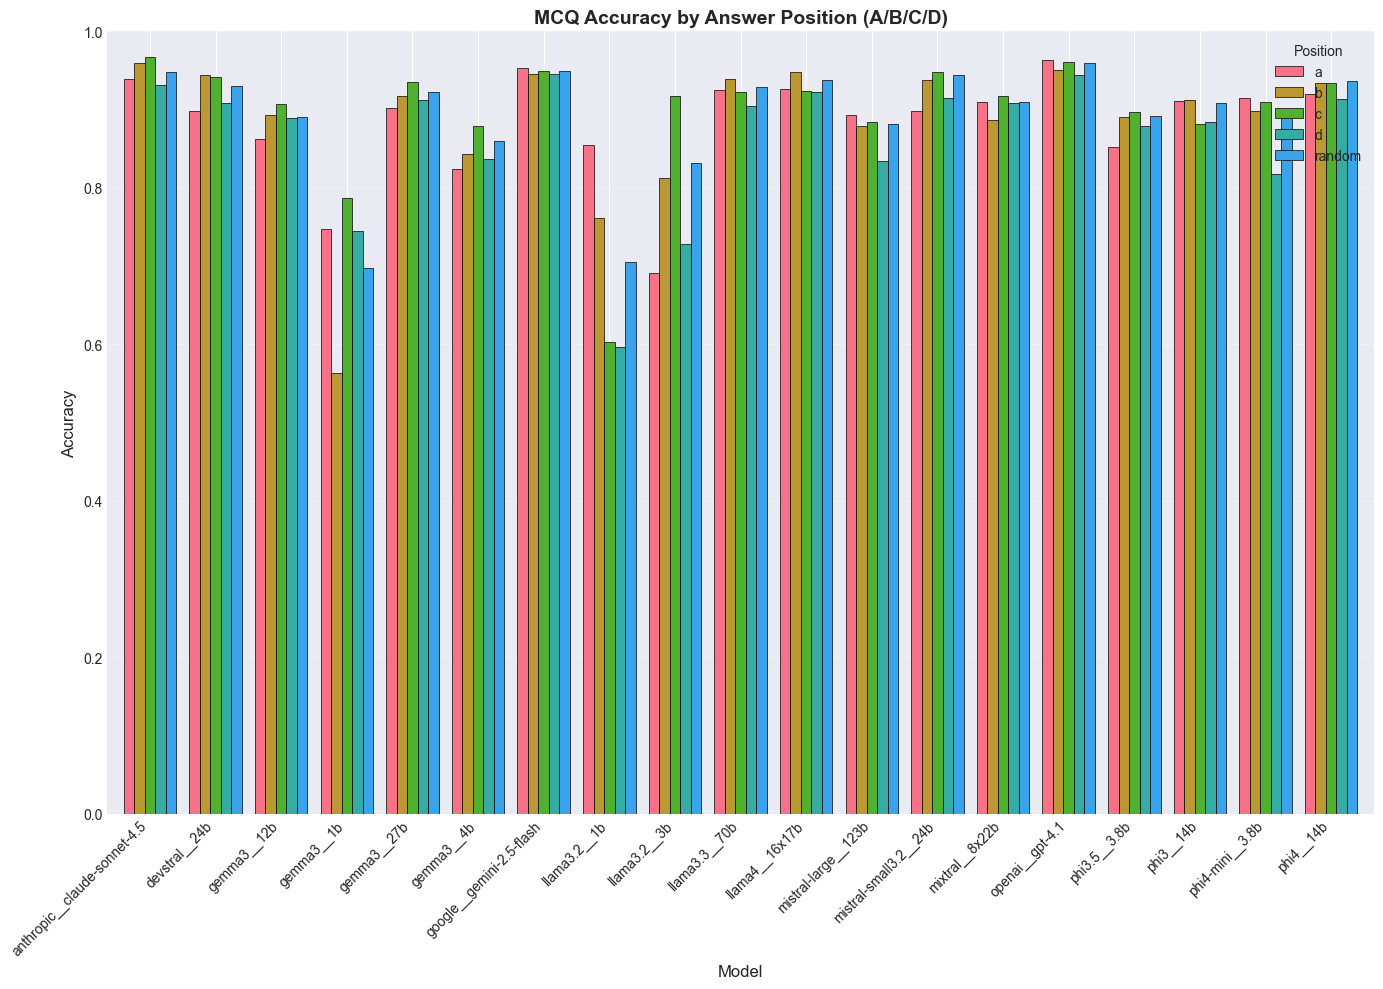

✅ Saved: output_v2/fig_mcq_position_accuracy.png


In [22]:
print('\n📊 PLOT 1: Accuracy by Position\n')

fig, ax = plt.subplots(figsize=(14, 10))

# Grouped bar chart
acc_pivot.plot(
    kind='bar',
    ax=ax,
    width=0.8,
    edgecolor='black',
    linewidth=0.5
)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('MCQ Accuracy by Answer Position (A/B/C/D)', 
             fontsize=14, fontweight='bold')
ax.legend(title='Position', fontsize=10)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(output_dir / 'fig_mcq_position_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✅ Saved: {output_dir}/fig_mcq_position_accuracy.png')

### 2.3 Visual Diagnostic: Deviation from Uniform


📊 PLOT 2: Deviation from Uniform

Deviation from Uniform (first 5 models):
variant                              a         b         c         d    random
model                                                                         
anthropic__claude-sonnet-4.5 -0.009615  0.009615  0.018357 -0.017483 -0.000874
devstral__24b                -0.026573  0.019755  0.017133 -0.016084  0.005769
gemma3__12b                  -0.025874  0.004720  0.018706  0.000350  0.002098
gemma3__1b                    0.039510 -0.144930  0.078846  0.036888 -0.010315
gemma3__27b                  -0.015559 -0.000699  0.017657 -0.005944  0.004545


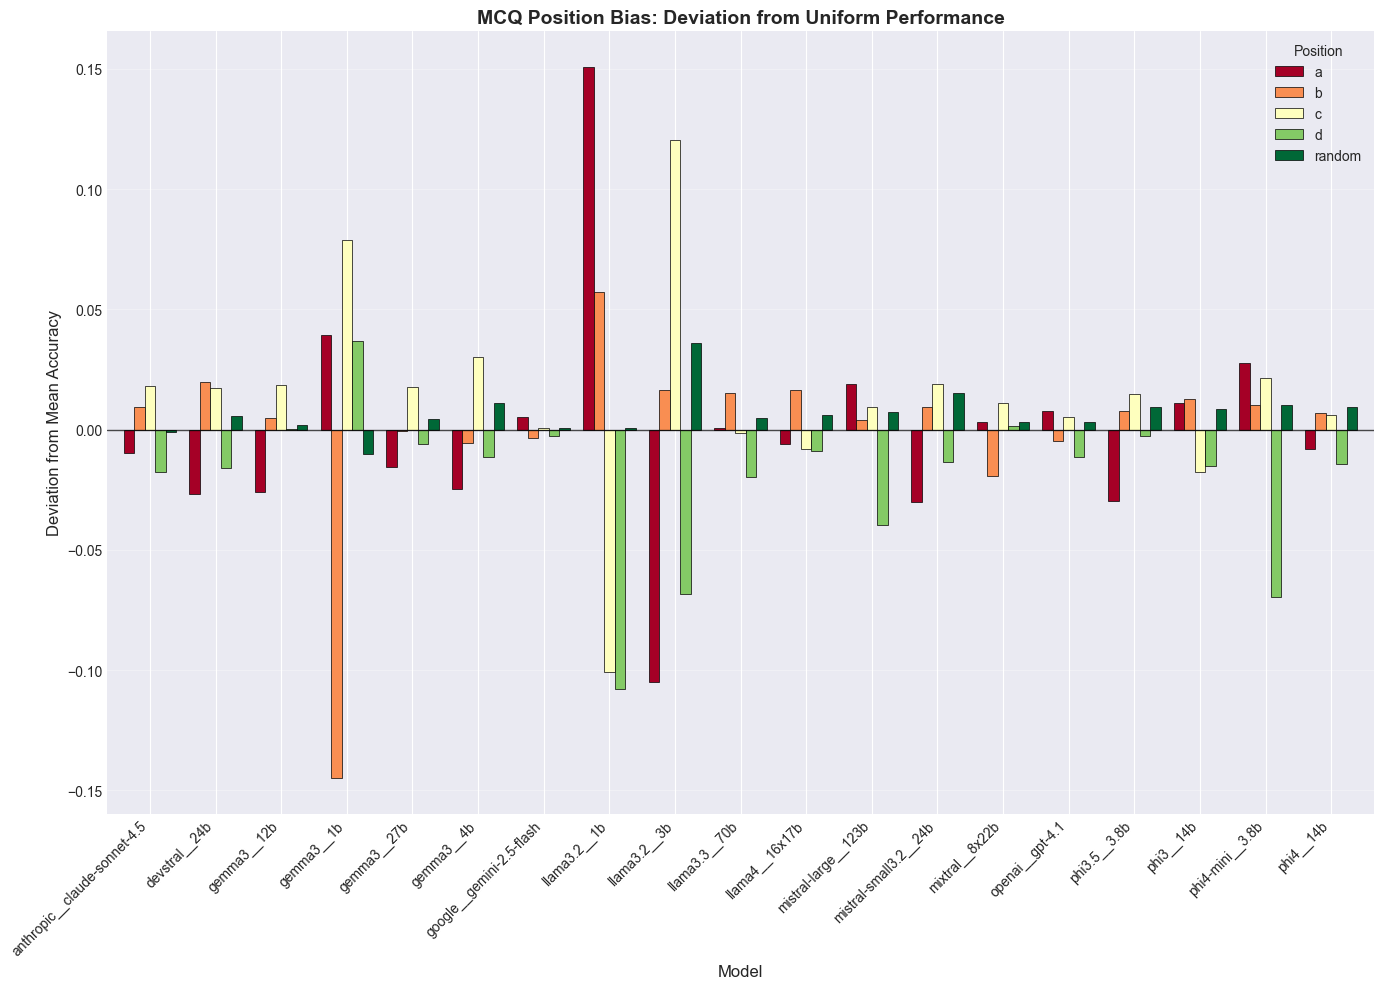

✅ Saved: output_v2/fig_mcq_deviation_uniform.png


In [23]:
print('\n📊 PLOT 2: Deviation from Uniform\n')

# Calculate deviation from uniform baseline
# Δ_p = Acc_p - (1/4)Σ Acc_i
uniform_baseline = acc_pivot.mean(axis=1)
deviation = acc_pivot.subtract(uniform_baseline, axis=0)

print('Deviation from Uniform (first 5 models):')
print(deviation.head())

fig, ax = plt.subplots(figsize=(14, 10))

# Grouped bar chart showing deviations
deviation.plot(
    kind='bar',
    ax=ax,
    width=0.8,
    edgecolor='black',
    linewidth=0.5,
    colormap='RdYlGn'
)

ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Deviation from Mean Accuracy', fontsize=12)
ax.set_title('MCQ Position Bias: Deviation from Uniform Performance', 
             fontsize=14, fontweight='bold')
ax.legend(title='Position', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(output_dir / 'fig_mcq_deviation_uniform.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✅ Saved: {output_dir}/fig_mcq_deviation_uniform.png')

### 2.4 Statistical Test: Chi-Square Test of Independence

In [25]:
print('\n📊 Chi-Square Test of Independence\n')
print('H₀: Answer position does not affect correctness\n')

chi_square_results = []

for model in common_models:
    model_data = mcq_df[mcq_df['model'] == model]
    
    # Create 2×4 contingency table
    # Rows: correct (True/False)
    # Columns: variants (A/B/C/D)
    contingency = pd.crosstab(
        model_data['is_correct'],
        model_data['variant']
    )
    
    # Chi-square test
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
    
    # Cramér's V (effect size)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    cramers_v = np.sqrt(chi2_stat / (n * min_dim))
    
    chi_square_results.append({
        'model': model,
        'chi2_stat': chi2_stat,
        'p_value': p_value,
        'dof': dof,
        'cramers_v': cramers_v,
        'n_observations': int(n),
        'significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_square_df = pd.DataFrame(chi_square_results)

print('Chi-Square Test Results (first 10 models):')
print(chi_square_df.head(10).to_string(index=False))

# Summary statistics
n_significant = (chi_square_df['p_value'] < 0.05).sum()
print(f'\nSignificant results (p < 0.05): {n_significant}/{len(chi_square_df)}')
print(f"Mean Cramér's V: {chi_square_df['cramers_v'].mean():.4f}")
print(f"Median Cramér's V: {chi_square_df['cramers_v'].median():.4f}")


📊 Chi-Square Test of Independence

H₀: Answer position does not affect correctness

Chi-Square Test Results (first 10 models):
                       model  chi2_stat      p_value  dof  cramers_v  n_observations significant
anthropic__claude-sonnet-4.5  19.687814 5.754815e-04    4   0.058668            5720         Yes
               devstral__24b  27.499724 1.575066e-05    4   0.069337            5720         Yes
                 gemma3__12b  12.094095 1.666510e-02    4   0.045982            5720         Yes
                  gemma3__1b 167.345541 3.882588e-35    4   0.171044            5720         Yes
                 gemma3__27b   9.240737 5.535594e-02    4   0.040193            5720          No
                  gemma3__4b  16.166000 2.804316e-03    4   0.053162            5720         Yes
    google__gemini-2.5-flash   1.125897 8.901419e-01    4   0.014030            5720          No
                llama3.2__1b 262.768709 1.154347e-55    4   0.214333            5720         Yes

In [26]:
# Export chi-square results
chi_square_df.to_csv(output_dir / 'table_chi_square_position_bias.csv', index=False)
export_latex_table(
    chi_square_df[['model', 'chi2_stat', 'p_value', 'cramers_v', 'significant']],
    'table_chi_square_position_bias.tex',
    'Chi-Square Test Results for Position Bias',
    'tab:chi_square_position'
)

   ✓ Exported: table_chi_square_position_bias.tex


### 2.5 Statistical Test: Friedman Test (Repeated Measures)

In [31]:
print('\n📊 Friedman Test (Repeated Measures)\n')
print('H₀: Per-question correctness does not differ across positions\n')

friedman_results = []

for model in common_models:
    model_data = mcq_df[mcq_df['model'] == model]
    
    # Pivot to repeated measures format
    # Rows: questions, Columns: variants (A/B/C/D)
    repeated_measures = model_data.pivot(
        index='question_id',
        columns='variant',
        values='is_correct'
    )
    
    # Drop questions with missing positions (if any)
    repeated_measures = repeated_measures.dropna()
    
    if len(repeated_measures) > 0:
        # Friedman test requires arrays for each condition
        position_arrays = [
            repeated_measures['a'].values,
            repeated_measures['b'].values,
            repeated_measures['c'].values,
            repeated_measures['d'].values
        ]
        
        # Friedman test
        friedman_stat, p_value = friedmanchisquare(*position_arrays)
        
        # Kendall's W (effect size for Friedman)
        n_subjects = len(repeated_measures)
        k_conditions = 4
        kendalls_w = friedman_stat / (n_subjects * (k_conditions - 1))
        
        friedman_results.append({
            'model': model,
            'friedman_stat': friedman_stat,
            'p_value': p_value,
            'kendalls_w': kendalls_w,
            'n_questions': int(n_subjects),
            'significant': 'Yes' if p_value < 0.05 else 'No'
        })

friedman_df = pd.DataFrame(friedman_results)

print('Friedman Test Results (first 10 models):')
print(friedman_df.head(10).to_string(index=False))

# Summary statistics
n_significant = (friedman_df['p_value'] < 0.05).sum()
print(f'\nSignificant results (p < 0.05): {n_significant}/{len(friedman_df)}')
print(f"Mean Kendall's W: {friedman_df['kendalls_w'].mean():.4f}")
print(f"Median Kendall's W: {friedman_df['kendalls_w'].median():.4f}")


📊 Friedman Test (Repeated Measures)

H₀: Per-question correctness does not differ across positions

Friedman Test Results (first 10 models):
                       model  friedman_stat      p_value  kendalls_w  n_questions significant
anthropic__claude-sonnet-4.5      46.238434 5.046594e-10    0.013473         1144         Yes
               devstral__24b      58.151242 1.459226e-12    0.016944         1144         Yes
                 gemma3__12b      30.721805 9.727727e-07    0.008952         1144         Yes
                  gemma3__1b     285.097649 1.670261e-61    0.083070         1144         Yes
                 gemma3__27b      22.722772 4.612852e-05    0.006621         1144         Yes
                  gemma3__4b      38.892857 1.828786e-08    0.011332         1144         Yes
    google__gemini-2.5-flash       3.476636 3.238051e-01    0.001013         1144          No
                llama3.2__1b     446.622103 1.758417e-96    0.130135         1144         Yes
            

In [32]:
# Export Friedman results
friedman_df.to_csv(output_dir / 'table_friedman_position_bias.csv', index=False)
export_latex_table(
    friedman_df[['model', 'friedman_stat', 'p_value', 'kendalls_w', 'significant']],
    'table_friedman_position_bias.tex',
    'Friedman Test Results for Position Bias',
    'tab:friedman_position'
)

   ✓ Exported: table_friedman_position_bias.tex


### 2.6 Effect Size Visualization: Cramér's V


📊 PLOT 3: Cramér's V Effect Sizes



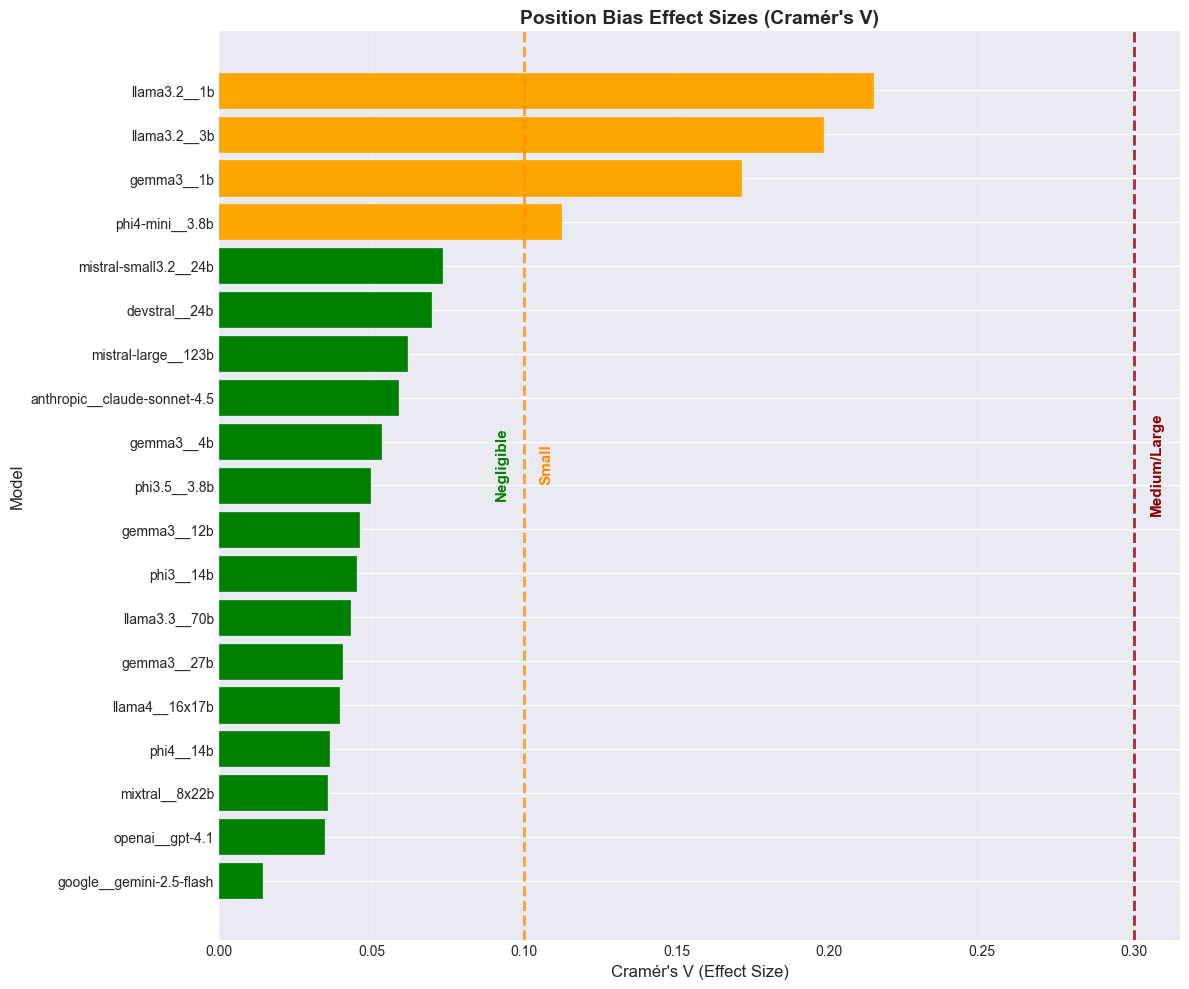

✅ Saved: output_v2/fig_cramers_v_position_bias.png


In [37]:
print("\n📊 PLOT 3: Cramér's V Effect Sizes\n")

fig, ax = plt.subplots(figsize=(12, 10))

# Sort by Cramér's V
chi_square_df_sorted = chi_square_df.sort_values('cramers_v', ascending=True)

bars = ax.barh(
    chi_square_df_sorted['model'],
    chi_square_df_sorted['cramers_v'],
    edgecolor='black',
    linewidth=0.5
)

# Color bars by effect size magnitude
colors = []
for v in chi_square_df_sorted['cramers_v']:
    if v < 0.10:
        colors.append('green')      # Negligible
    elif v < 0.30:
        colors.append('orange')     # Moderate
    else:
        colors.append('red')        # Strong

for bar, color in zip(bars, colors):
    bar.set_color(color)

# Reference lines - made more visible with higher alpha and thicker lines
ax.axvline(0.10, color='darkorange', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(0.30, color='darkred', linestyle='--', linewidth=2, alpha=0.8)

# Add zone labels rotated 90 degrees, positioned next to the reference lines
y_mid = len(chi_square_df_sorted) / 2  # Vertical center of chart

# "Negligible" - to the left of the 0.10 line
ax.text(0.095, y_mid, 'Negligible', fontsize=11, fontweight='bold', 
        color='green', ha='right', va='center', rotation=90)

# "Small" - to the right of the 0.10 line
ax.text(0.105, y_mid, 'Small', fontsize=11, fontweight='bold', 
        color='darkorange', ha='left', va='center', rotation=90)

# "Medium/Large" - to the right of the 0.30 line
ax.text(0.305, y_mid, 'Medium/Large', fontsize=11, fontweight='bold', 
        color='darkred', ha='left', va='center', rotation=90)

ax.set_xlabel("Cramér's V (Effect Size)", fontsize=12)
ax.set_ylabel('Model', fontsize=12)
ax.set_title("Position Bias Effect Sizes (Cramér's V)", 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'fig_cramers_v_position_bias.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✅ Saved: {output_dir}/fig_cramers_v_position_bias.png')

### 2.7 Interpretation

In [38]:
def interpret_position_bias(chi2_p, cramers_v, friedman_p):
    """
    Apply manuscript interpretation logic for position bias.
    
    Parameters:
    -----------
    chi2_p : float
        Chi-square p-value
    cramers_v : float
        Cramér's V effect size
    friedman_p : float
        Friedman test p-value
    
    Returns:
    --------
    tuple : (category, description)
    """
    # Step 1: Check chi-square significance
    chi2_sig = chi2_p < 0.05
    
    # Step 2: Assess magnitude (Cramér's V)
    if cramers_v < 0.10:
        v_interp = 'negligible'
    elif cramers_v < 0.30:
        v_interp = 'moderate'
    else:
        v_interp = 'strong'
    
    # Step 3: Check Friedman significance
    friedman_sig = friedman_p < 0.05
    
    # Step 4: Final interpretation
    if not chi2_sig and cramers_v < 0.10:
        category = 'No bias'
        description = 'MCQ accuracy is position-invariant'
    elif chi2_sig and cramers_v < 0.10 and not friedman_sig:
        category = 'Mild bias'
        description = 'Statistically significant but small effect'
    elif chi2_sig and 0.10 <= cramers_v < 0.30:
        category = 'Moderate bias'
        description = 'Position should be considered in interpretation'
    elif chi2_sig and cramers_v >= 0.30 and friedman_sig:
        category = 'Strong bias'
        description = 'MCQ accuracy heavily confounded by position'
    else:
        category = 'Mixed evidence'
        description = 'Inconsistent evidence across tests'
    
    return category, description


print('\n📋 Position Bias Interpretation\n')

# Apply to all models
interpretations = []
for idx, row in chi_square_df.iterrows():
    friedman_row = friedman_df[friedman_df['model'] == row['model']]
    
    if len(friedman_row) > 0:
        friedman_p = friedman_row['p_value'].values[0]
    else:
        friedman_p = 1.0  # Conservative if missing
    
    category, description = interpret_position_bias(
        row['p_value'],
        row['cramers_v'],
        friedman_p
    )
    
    interpretations.append({
        'model': row['model'],
        'category': category,
        'description': description,
        'chi2_p': row['p_value'],
        'cramers_v': row['cramers_v'],
        'friedman_p': friedman_p
    })

interpretation_df = pd.DataFrame(interpretations)

print('Position Bias Interpretation (first 10 models):')
print(interpretation_df[['model', 'category', 'cramers_v']].head(10).to_string(index=False))

# Summary
print('\nInterpretation Summary:')
print(interpretation_df['category'].value_counts())


📋 Position Bias Interpretation

Position Bias Interpretation (first 10 models):
                       model       category  cramers_v
anthropic__claude-sonnet-4.5 Mixed evidence   0.058668
               devstral__24b Mixed evidence   0.069337
                 gemma3__12b Mixed evidence   0.045982
                  gemma3__1b  Moderate bias   0.171044
                 gemma3__27b        No bias   0.040193
                  gemma3__4b Mixed evidence   0.053162
    google__gemini-2.5-flash        No bias   0.014030
                llama3.2__1b  Moderate bias   0.214333
                llama3.2__3b  Moderate bias   0.197910
               llama3.3__70b Mixed evidence   0.042965

Interpretation Summary:
category
Mixed evidence    9
No bias           6
Moderate bias     4
Name: count, dtype: int64


In [39]:
# Export interpretation
interpretation_df.to_csv(output_dir / 'table_position_bias_interpretation.csv', index=False)
export_latex_table(
    interpretation_df[['model', 'category', 'cramers_v', 'chi2_p', 'friedman_p']],
    'table_position_bias_interpretation.tex',
    'Position Bias Interpretation Summary',
    'tab:position_interpretation'
)

   ✓ Exported: table_position_bias_interpretation.tex


---
## 3. OSQ SCORING ANALYSIS

### 3.0 Structural Components

**Analytical Question**

We characterize model performance on open short-answer questions (OSQs) and assess the consistency of LLM-based judges scoring responses with a multi-dimensional rubric.

**Threat to Validity**

If OSQ scores are unstable or judge-specific, then model rankings and conclusions about higher-order reasoning may depend more on the choice of judge than on true model capability. This would weaken the validity of OSQ as a complementary evaluation to MCQ.

**Evidence Requirements**

We require:
1. A clear description of OSQ score distributions (central tendency and variability).
2. Evidence that different judges assign similar scores to the same models or responses.
3. Robust estimates of mean performance that do not rely on normality assumptions.

### 3.1 Visual Diagnostic: Score Distribution Plots (Histogram + KDE)


📊 OSQ Score Distribution Plots by Judge (Overlayed KDE)

Creating KDE overlay plots for 2 judges
Models detected: 19

--- Judge: gpt-oss_120b ---


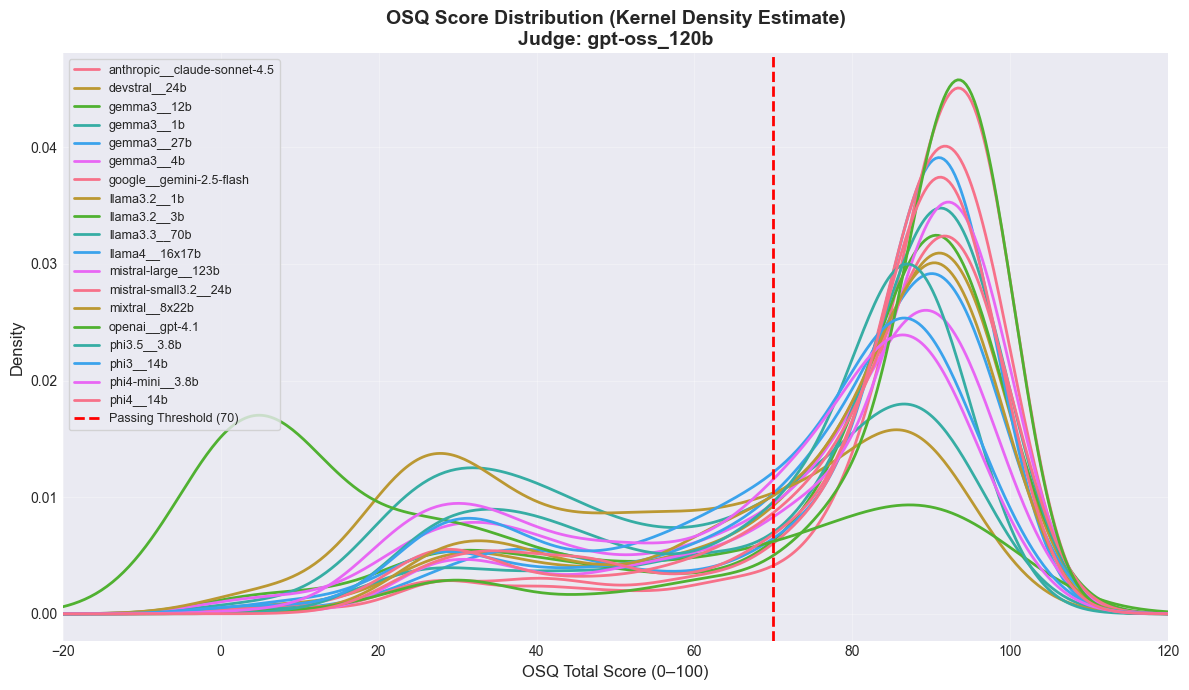

  ✅ Saved to output_v2\osq_score_kde_gpt-oss_120b.png

--- Judge: openai_gpt-5-mini ---


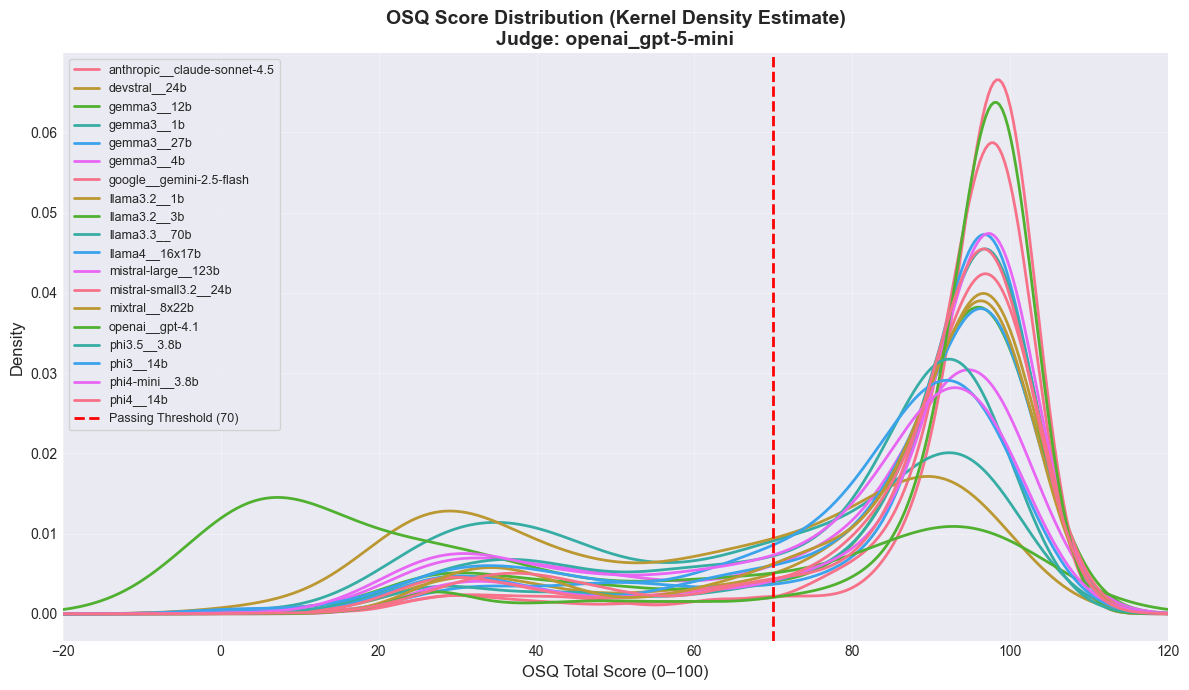

  ✅ Saved to output_v2\osq_score_kde_openai_gpt-5-mini.png

✅ All judge KDE plots saved to output_v2/


In [47]:
print('\n📊 OSQ Score Distribution Plots by Judge (Overlayed KDE)\n')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Parameters (match reference image)
PASSING_THRESHOLD = 70
X_MIN, X_MAX = -20, 120
N_POINTS = 400

judges = sorted(osq_filtered['judge_model'].unique())
models = sorted(osq_filtered['model'].unique())

print(f'Creating KDE overlay plots for {len(judges)} judges')
print(f'Models detected: {len(models)}')

for judge in judges:
    print(f'\n--- Judge: {judge} ---')

    judge_data = osq_filtered[osq_filtered['judge_model'] == judge]
    judge_models = sorted(judge_data['model'].unique())

    if len(judge_models) == 0:
        print(f'  ⚠️ No data for judge {judge}')
        continue

    fig, ax = plt.subplots(figsize=(12, 7))

    x_grid = np.linspace(X_MIN, X_MAX, N_POINTS)

    for model in judge_models:
        scores = (
            judge_data[judge_data['model'] == model]['total_score']
            .dropna()
            .astype(float)
        )

        # Skip insufficient data
        if len(scores) < 5 or scores.std() == 0:
            print(f'  ⚠️ Skipping {model} (insufficient variance)')
            continue

        try:
            kde = gaussian_kde(scores)
            ax.plot(
                x_grid,
                kde(x_grid),
                linewidth=2,
                label=model
            )
        except Exception as e:
            print(f'  ⚠️ KDE failed for {model}: {e}')

    # Passing threshold line
    ax.axvline(
        PASSING_THRESHOLD,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Passing Threshold ({PASSING_THRESHOLD})'
    )

    # Styling to match reference
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_xlabel('OSQ Total Score (0–100)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(
        f'OSQ Score Distribution (Kernel Density Estimate)\nJudge: {judge}',
        fontsize=14,
        fontweight='bold'
    )

    ax.grid(True, alpha=0.3)
    ax.legend(
        loc='upper left',
        fontsize=9,
        frameon=True,
        ncol=1
    )

    plt.tight_layout()

    # Save
    safe_judge = judge.replace('/', '_').replace(':', '_')
    save_path = output_dir / f'osq_score_kde_{safe_judge}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f'  ✅ Saved to {save_path}')

print(f'\n✅ All judge KDE plots saved to {output_dir}/')


### 3.2 Visual Diagnostic: Judge-Level Box/Violin Plots


📊 OSQ Score Distributions by Model (One Plot per Judge)

Creating violin plots for 2 judges: ['gpt-oss_120b', 'openai_gpt-5-mini']

--- Judge: gpt-oss_120b ---


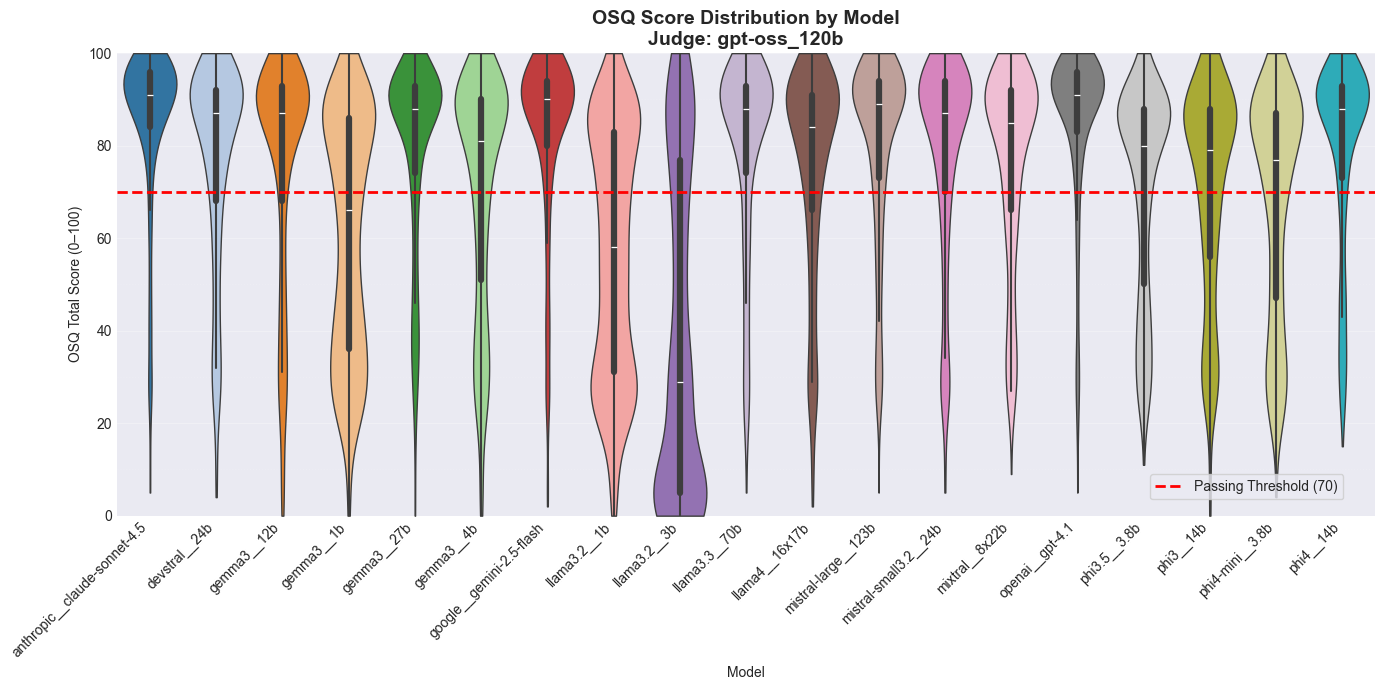

  ✅ Saved to output_v2\osq_model_violin_gpt-oss_120b.png

--- Judge: openai_gpt-5-mini ---


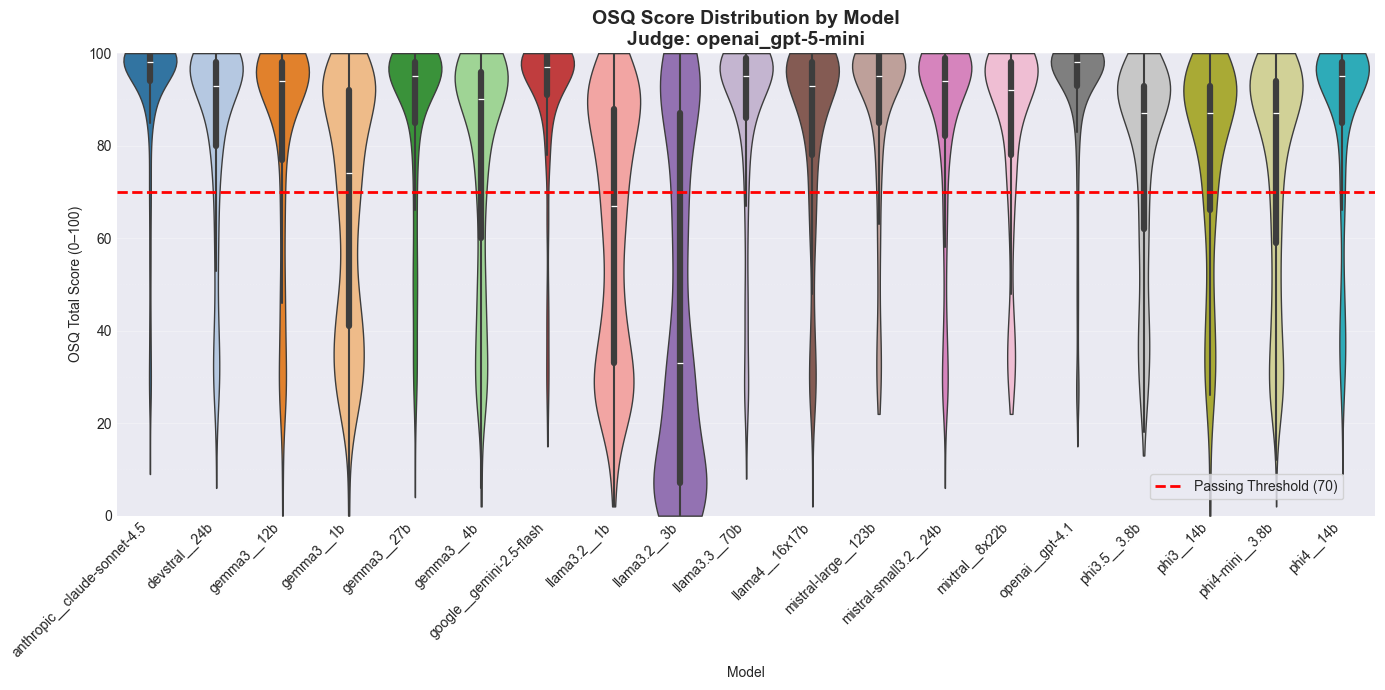

  ✅ Saved to output_v2\osq_model_violin_openai_gpt-5-mini.png

✅ All judge-level violin plots saved to output_v2/


In [ ]:
print('\n📊 OSQ Score Distributions by Model (One Plot per Judge)\n')

import matplotlib.pyplot as plt
import seaborn as sns

PASSING_THRESHOLD = 70
Y_MIN, Y_MAX = -20, 120

# Get unique judges
judges = sorted(osq_filtered['judge_model'].unique())

print(f'Creating violin plots for {len(judges)} judges: {judges}')

for judge in judges:
    print(f'\n--- Judge: {judge} ---')

    judge_df = osq_filtered[osq_filtered['judge_model'] == judge]

    if judge_df.empty:
        print(f'  ⚠️ No data for judge {judge}')
        continue

    fig, ax = plt.subplots(figsize=(14, 7))

    # Violin plot: model distributions for this judge
    sns.violinplot(
        data=judge_df,
        x='model',
        y='total_score',
        ax=ax,
        palette='tab20',
        cut=0,
        inner='box',
        linewidth=1
    )

    # Passing threshold
    ax.axhline(
        PASSING_THRESHOLD,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Passing Threshold ({PASSING_THRESHOLD})'
    )

    # Styling to match reference
    # ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Model')
    ax.set_ylabel('OSQ Total Score (0–100)')
    # Y-axis ticks and gridlines
    ax.set_yticks(range(0, 101, 20))
    ax.set_yticks(range(0, 101, 10), minor=True)

    ax.grid(True, axis='y', which='major', linestyle='-', alpha=0.25)
    ax.grid(True, axis='y', which='minor', linestyle=':', alpha=0.15)

    ax.set_title(
        f'OSQ Score Distribution by Model\nJudge: {judge}',
        fontsize=14,
        fontweight='bold'
    )

    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    # ax.legend()
    ax.legend(
    loc='lower right',
    bbox_to_anchor=(0.98, 0.02),
    frameon=True
    )


    plt.tight_layout()

    # Save figure
    safe_judge = judge.replace('/', '_').replace(':', '_')
    save_path = output_dir / f'osq_model_violin_{safe_judge}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f'  ✅ Saved to {save_path}')

print(f'\n✅ All judge-level violin plots saved to {output_dir}/')


### 3.3 Visual Diagnostic: Rubric Dimension Bar Charts

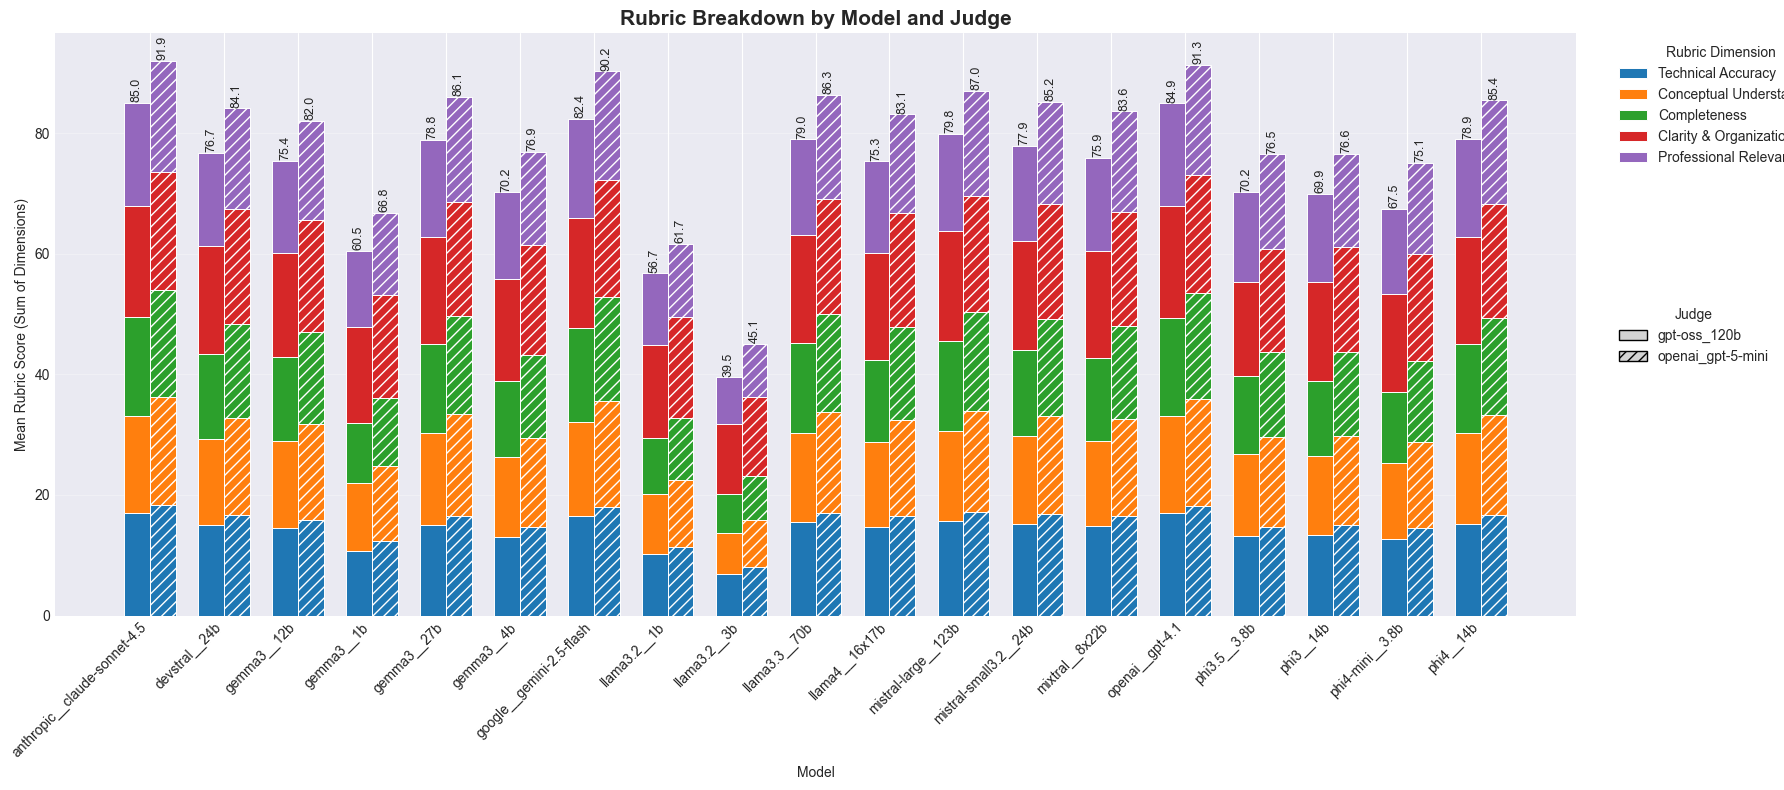

In [ ]:
# ============================================================
# Grouped (Judges) + Stacked (Rubrics) Bar Chart
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------
# Assuming osq_filtered DataFrame is available
# with columns: 'model', 'judge_model', and rubric score columns
# -------------------------

# -------------------------
# REQUIRED RUBRIC CONFIG
# -------------------------
RUBRIC_COLS = [
    'technical_accuracy',
    'conceptual_understanding',
    'completeness',
    'clarity_organization',
    'professional_relevance'
]

RUBRIC_LABELS = [
    'Technical Accuracy',
    'Conceptual Understanding',
    'Completeness',
    'Clarity & Organization',
    'Professional Relevance'
]

# -------------------------
# Aggregate mean rubric scores
# (Model × Judge × Rubric)
# -------------------------
agg_df = (
    osq_filtered
    .groupby(['model', 'judge_model'])[RUBRIC_COLS]
    .mean()
    .reset_index()
)

# -------------------------
# Axes setup
# -------------------------
models = agg_df['model'].unique()
judges = agg_df['judge_model'].unique()

x = np.arange(len(models))
bar_width = 0.35

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(18, 8))

rubric_colors = plt.cm.tab10.colors
HATCH_PATTERNS = ['', '///', '..', 'xx']

for j, judge in enumerate(judges):
    judge_df = agg_df[agg_df['judge_model'] == judge]
    bottom = np.zeros(len(models))
    current_hatch = HATCH_PATTERNS[j % len(HATCH_PATTERNS)]

    # Build stacked bars
    for i, (rubric, label) in enumerate(zip(RUBRIC_COLS, RUBRIC_LABELS)):
        values = (
            judge_df
            .set_index('model')
            .reindex(models)[rubric]
            .fillna(0)
            .values
        )

        ax.bar(
            x + j * bar_width,
            values,
            bar_width,
            bottom=bottom,
            color=rubric_colors[i % len(rubric_colors)],
            hatch=current_hatch,
            edgecolor='white',
            linewidth=0.7,
            label=label if j == 0 else None
        )

        bottom += values

    # Annotate totals
    for xi, total in zip(x + j * bar_width, bottom):
        ax.text(
            xi,
            total + 0.1,
            f'{total:.1f}',
            ha='center',
            va='bottom',
            rotation=90,
            fontsize=9
        )

# -------------------------
# Axes formatting
# -------------------------
ax.set_title(
    'Rubric Breakdown by Model and Judge',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Model')
ax.set_ylabel('Mean Rubric Score (Sum of Dimensions)')

center_offset = ((len(judges) - 1) * bar_width) / 2
ax.set_xticks(x + center_offset)
ax.set_xticklabels(models, rotation=45, ha='right')

ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)

# -------------------------
# Legends
# -------------------------
rubric_legend = ax.legend(
    title='Rubric Dimension',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

judge_handles = [
    Patch(
        facecolor='lightgray',
        edgecolor='black',
        hatch=HATCH_PATTERNS[k % len(HATCH_PATTERNS)],
        label=judge
    )
    for k, judge in enumerate(judges)
]

ax.add_artist(rubric_legend)
ax.legend(
    handles=judge_handles,
    title='Judge',
    bbox_to_anchor=(1.02, 0.55),
    loc='upper left'
)

plt.tight_layout()
plt.show()


### 3.4 Descriptive Statistics

In [30]:
print('\n📊 OSQ Descriptive Statistics\n')

# Per-model statistics
print('='*80)
print('PER-MODEL STATISTICS')
print('='*80)

model_stats = osq_df.groupby('model')['total_score'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ('Min', 'min'),
    ('Max', 'max')
]).round(3)

print(model_stats.to_string())

# Per-judge statistics
print('\n' + '='*80)
print('PER-JUDGE STATISTICS')
print('='*80)

judge_stats = osq_df.groupby('judge_model')['total_score'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ('Min', 'min'),
    ('Max', 'max')
]).round(3)

print(judge_stats.to_string())

print('\n✅ Descriptive statistics computed')


📊 OSQ Descriptive Statistics

PER-MODEL STATISTICS
                              Count    Mean  Median  Std Dev    IQR   Min    Max
model                                                                           
anthropic__claude-sonnet-4.5   2525  88.977    96.0   17.957  12.00   5.0  100.0
devstral__24b                  2532  80.222    90.0   22.952  25.25   4.0  100.0
gemma3__12b                    2535  77.591    90.0   25.822  29.00   0.0  100.0
gemma3__1b                     2534  60.793    65.0   27.702  52.00   0.0  100.0
gemma3__27b                    2533  81.567    91.0   22.316  21.00   0.0  100.0
gemma3__4b                     2534  71.804    84.0   26.896  44.00   0.0  100.0
google__gemini-2.5-flash       2532  86.850    94.0   18.954  14.00   2.0  100.0
llama3.2__1b                   2534  56.916    58.0   27.740  54.00   0.0  100.0
llama3.2__3b                   2530  41.542    30.0   36.023  74.00   0.0  100.0
llama3.3__70b                  2534  82.502    91.0   21.

### 3.5 Visual Diagnostics Summary

The above subsections provide comprehensive visual diagnostics for OSQ performance:

- **3.1**: Score distributions reveal the shape, spread, and skewness of model performance
- **3.2**: Judge-level distributions expose systematic differences in scoring behavior
- **3.3**: Rubric dimension analysis highlights dimension-specific strengths and weaknesses
- **3.4**: Descriptive statistics provide numerical summaries of central tendency and variability

These diagnostics inform the statistical tests and interpretation that follow.

### 3.6 Inter-Judge Agreement (Spearman Correlation)

In [31]:
print('\n📊 Inter-Judge Agreement Analysis\n')

if len(COMPLETE_JUDGES) >= 2:
    # Pivot for judge comparison
    judge_pivot = osq_filtered.pivot_table(
        index=['model', 'question_id'],
        columns='judge_model',
        values='total_score'
    )
    
    # Pairwise correlations
    correlations = []
    for judge1, judge2 in combinations(COMPLETE_JUDGES, 2):
        valid_data = judge_pivot[[judge1, judge2]].dropna()
        
        if len(valid_data) > 0:
            rho, p_value = spearmanr(valid_data[judge1], valid_data[judge2])
            
            correlations.append({
                'judge_1': judge1,
                'judge_2': judge2,
                'spearman_rho': rho,
                'p_value': p_value,
                'n': len(valid_data)
            })
    
    corr_df = pd.DataFrame(correlations)
    
    # Average correlation
    if len(corr_df) > 0:
        avg_rho = corr_df['spearman_rho'].mean()
        print(f'Inter-Judge Correlations:')
        print(corr_df.to_string(index=False))
        print(f'\nAverage Spearman correlation: {avg_rho:.3f}')
        
        # Export
        corr_df.to_csv(output_dir / 'table_interjudge_correlation.csv', index=False)
        export_latex_table(
            corr_df,
            'table_interjudge_correlation.tex',
            'Inter-Judge Agreement (Spearman Correlation)',
            'tab:interjudge_corr'
        )
    else:
        print('Not enough judge pairs for correlation analysis')
else:
    print('Only one judge available - skipping inter-judge correlation')


📊 Inter-Judge Agreement Analysis

Inter-Judge Correlations:
     judge_1           judge_2  spearman_rho  p_value     n
gpt-oss_120b openai_gpt-5-mini      0.901209      0.0 16051

Average Spearman correlation: 0.901
   ✓ Exported: table_interjudge_correlation.tex


### 3.7 Bootstrap Confidence Intervals for OSQ Scores

In [32]:
print('\n📊 Bootstrap Confidence Intervals for OSQ Scores\n')

bootstrap_results_osq = []

for model in common_models:
    model_scores = osq_filtered[osq_filtered['model'] == model]['total_score'].values
    
    if len(model_scores) > 0:
        # Bootstrap using scipy
        rng = np.random.default_rng()
        res = bootstrap(
            (model_scores,),
            np.mean,
            n_resamples=N_BOOTSTRAP,
            confidence_level=CONFIDENCE_LEVEL,
            random_state=rng
        )
        
        bootstrap_results_osq.append({
            'model': model,
            'mean': model_scores.mean(),
            'ci_lower': res.confidence_interval.low,
            'ci_upper': res.confidence_interval.high,
            'ci_width': res.confidence_interval.high - res.confidence_interval.low
        })

bootstrap_osq_df = pd.DataFrame(bootstrap_results_osq)

print('Bootstrap CIs for OSQ (first 10 models):')
print(bootstrap_osq_df.head(10).to_string(index=False))

# Export
bootstrap_osq_df.to_csv(output_dir / 'table_osq_bootstrap_ci.csv', index=False)
export_latex_table(
    bootstrap_osq_df,
    'table_osq_bootstrap_ci.tex',
    'Bootstrap 95% Confidence Intervals for OSQ Scores',
    'tab:osq_bootstrap'
)


📊 Bootstrap Confidence Intervals for OSQ Scores

Bootstrap CIs for OSQ (first 10 models):
                       model      mean  ci_lower  ci_upper  ci_width
anthropic__claude-sonnet-4.5       NaN       NaN       NaN       NaN
               devstral__24b 80.407692 79.368122 81.428998  2.060876
                 gemma3__12b 78.728402 77.577016 79.973055  2.396039
                  gemma3__1b 63.650296 62.387053 64.904162  2.517109
                 gemma3__27b 82.445562 81.576744 83.442908  1.866164
                  gemma3__4b 73.537870 72.253192 74.711164  2.457973
    google__gemini-2.5-flash 86.300000 85.365336 87.140511  1.775175
                llama3.2__1b 59.198225 57.744259 60.405579  2.661320
                llama3.2__3b 42.295858 40.819841 44.059499  3.239658
               llama3.3__70b 82.644970 81.625521 83.596581  1.971059
   ✓ Exported: table_osq_bootstrap_ci.tex


### 3.8 OSQ Interpretation

In [34]:
print('\n📋 OSQ Analysis Interpretation\n')

# Inter-judge agreement interpretation
if 'corr_df' in locals() and len(corr_df) > 0:
    avg_rho = corr_df['spearman_rho'].mean()
    
    if avg_rho >= 0.80:
        judge_interp = 'High reliability: OSQ scores robust to judge choice'
    elif avg_rho >= 0.50:
        judge_interp = 'Moderate reliability: Acknowledge judge effects'
    else:
        judge_interp = 'Low reliability: OSQ conclusions exploratory'
    
    print(f'Inter-Judge Agreement: ρ={avg_rho:.3f}')
    print(f'Interpretation: {judge_interp}')
else:
    print('Inter-judge analysis not available (single judge)')

# Bootstrap CI width interpretation
avg_ci_width = bootstrap_osq_df['ci_width'].mean()
if avg_ci_width < 5.0:
    ci_interp = 'Narrow CIs: Stable mean estimates'
else:
    ci_interp = 'Wide CIs: High uncertainty'

print(f'\nBootstrap CI Width: {avg_ci_width:.2f}')
print(f'Interpretation: {ci_interp}')


📋 OSQ Analysis Interpretation

Inter-Judge Agreement: ρ=0.901
Interpretation: High reliability: OSQ scores robust to judge choice

Bootstrap CI Width: 2.21
Interpretation: Narrow CIs: Stable mean estimates


---
## 4. FORMAT COMPARISON: MCQ vs OSQ

Test whether MCQ and OSQ formats produce consistent assessments of model capability.

### Analyses:
1. **Visual Diagnostic:** MCQ-OSQ scatter plot (multi-judge)
2. **Correlation Analysis:** Pearson and Spearman (per judge + average)
3. **Paired Difference Test:** Wilcoxon signed-rank
4. **Effect Size:** Cohen's d
5. **Interpretation:** Apply manuscript decision logic

### 4.0 Structural Components

**Analytical Question**

We test whether multiple-choice (MCQ) and open short-answer (OSQ) formats produce consistent assessments of model capability on the same underlying questions, or whether they capture different aspects of performance.

**Threat to Validity**

If MCQ and OSQ results diverge, it is not valid to treat scores from the two formats as interchangeable. A model that performs well on MCQ may not perform equally well on OSQ, and overall conclusions about model capability will depend on format choice.

**Evidence Requirements**

We require:
1. A measure of association between MCQ accuracy and OSQ scores across models.
2. A paired comparison of per-model performance across formats on the matched question subset.
3. A standardized effect size describing any systematic difference between formats.

### 4.1 Visual: MCQ-OSQ Scatter Plot (Multi-Judge)

#### All Models Plotted by Judge

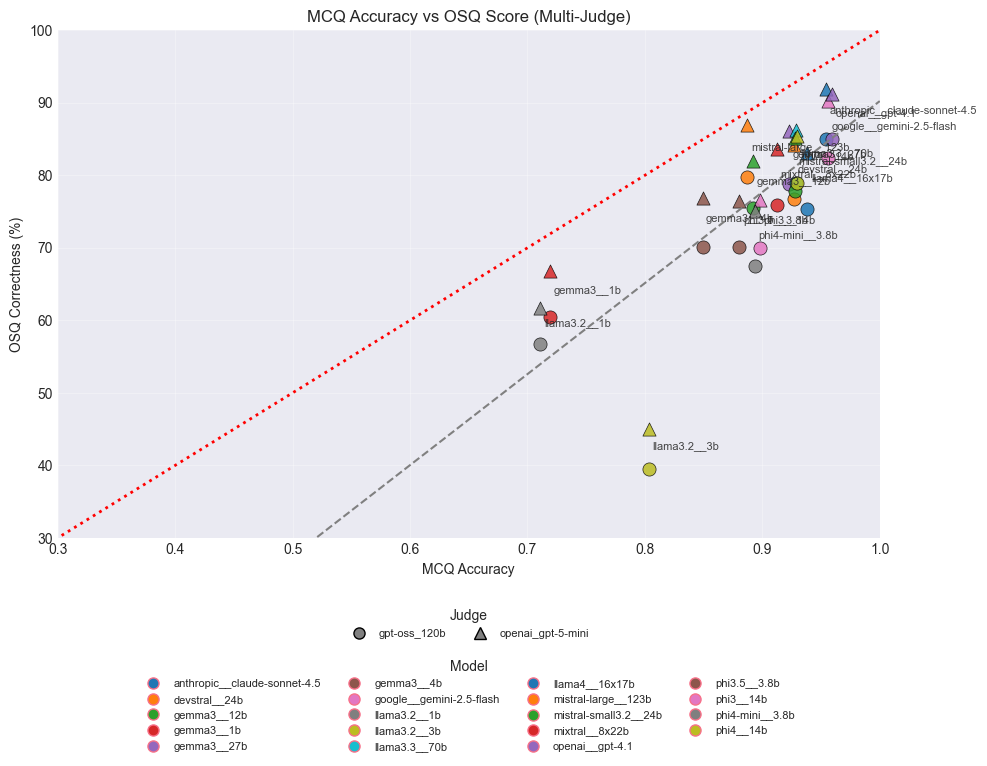

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from matplotlib.lines import Line2D

# -------------------------------
# Data
# -------------------------------

df = aligned_df_intersection

# -------------------------------
# Visual encodings
# -------------------------------

marker_cycle = ['o', '^', 's', 'D', 'v', 'P', 'X', '*', '<', '>']

judges = df['judge_model'].unique()
models = df['model'].unique()

judge_markers = {
    judge: marker_cycle[i % len(marker_cycle)]
    for i, judge in enumerate(judges)
}

model_colors = dict(
    zip(models, sns.color_palette('tab10', len(models)))
)

# -------------------------------
# MCQ aggregation (avg across judges)
# -------------------------------

mcq_by_model = (
    df
    .groupby('model')['mcq_avg_correct']
    .mean()
)

# -------------------------------
# Plot
# -------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: one point per (model, judge)
for judge in judges:
    df_j = df[df['judge_model'] == judge]

    for model in df_j['model'].unique():
        df_jm = df_j[df_j['model'] == model]

        ax.scatter(
            mcq_by_model[model],
            df_jm['osq_percentage'].mean(),
            color=model_colors[model],
            marker=judge_markers[judge],
            s=90,
            alpha=0.85,
            edgecolors='black',
            linewidths=0.5
        )

# -------------------------------
# Regression line (all judge points)
# -------------------------------

x = df['model'].map(mcq_by_model)
y = df['osq_percentage']

slope, intercept, r, p, _ = linregress(x, y)

x_line = np.linspace(0, 1, 200)
ax.plot(
    x_line,
    slope * x_line + intercept,
    '--',
    color='gray',
    linewidth=1.5,
    label=f'R² = {r**2:.3f}, p = {p:.4f}'
)

# -------------------------------
# Perfect agreement line (0,0 → 1,1)
# -------------------------------

ax.plot(
    [0, 1],
    [0, 100],
    ':',
    color='red',
    linewidth=2,
    label='Perfect Agreement'
)

# -------------------------------
# Model labels (centered vertically)
# -------------------------------

for model in models:
    ax.text(
        mcq_by_model[model] + 0.003,
        df[df['model'] == model]['osq_percentage'].mean(),
        model,
        fontsize=8,
        alpha=0.85
    )

# -------------------------------
# Legends (bottom, stacked)
# -------------------------------

judge_handles = [
    Line2D(
        [0], [0],
        marker=judge_markers[j],
        linestyle='None',
        markerfacecolor='gray',
        markeredgecolor='black',
        markersize=8,
        label=j
    )
    for j in judges
]

model_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=model_colors[m],
        markersize=8,
        label=m
    )
    for m in models
]

leg1 = ax.legend(
    handles=judge_handles,
    title='Judge',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=min(4, len(judges)),
    fontsize=8,
    frameon=False
)

ax.add_artist(leg1)

ax.legend(
    handles=model_handles,
    title='Model',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=min(4, len(models)),
    fontsize=8,
    frameon=False
)

# -------------------------------
# Axes & formatting
# -------------------------------

ax.set_xlabel('MCQ Accuracy')
ax.set_ylabel('OSQ Correctness (%)')
ax.set_title('MCQ Accuracy vs OSQ Score (Multi-Judge)')

ax.set_xlim(0.3, 1)
ax.set_ylim(30, 100)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### All Models Plotted with Average of All Judges

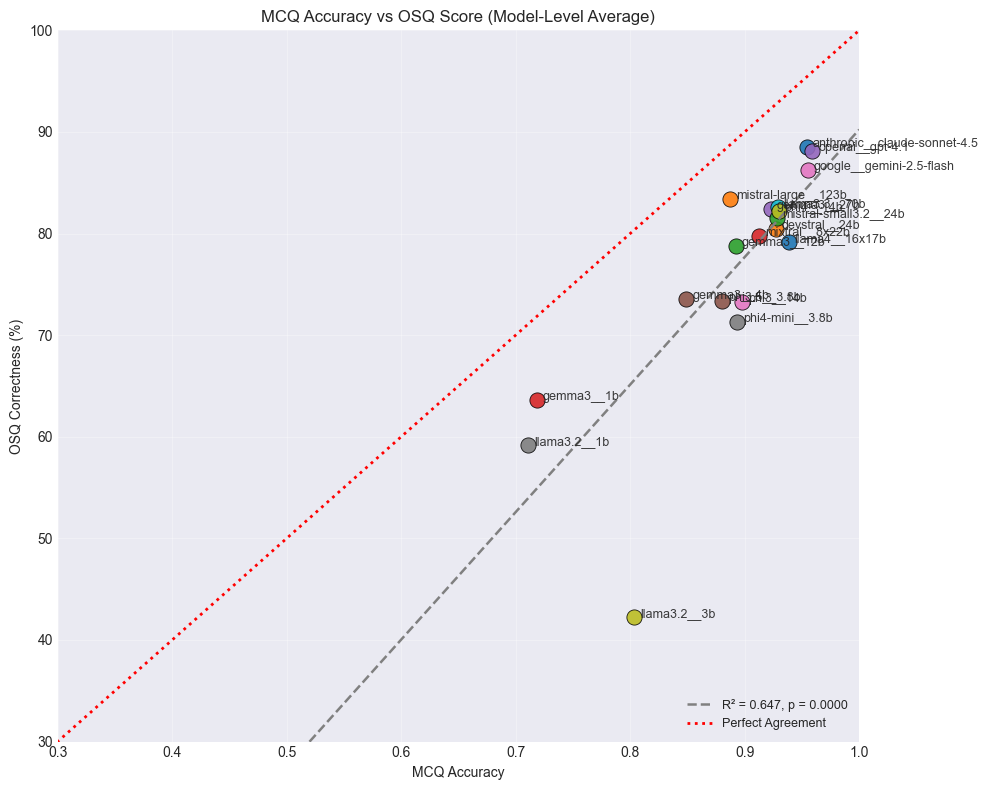

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from matplotlib.lines import Line2D

# -------------------------------
# Data
# -------------------------------

df = aligned_df_intersection

# -------------------------------
# Aggregate to MODEL LEVEL
# -------------------------------

# MCQ: already averaged correctly across judges
mcq_by_model = (
    df
    .groupby('model')['mcq_avg_correct']
    .mean()
)

# OSQ: average across judges (and questions)
osq_by_model = (
    df
    .groupby('model')['osq_percentage']
    .mean()
)

models = mcq_by_model.index

# -------------------------------
# Visual encodings
# -------------------------------

model_colors = dict(
    zip(models, sns.color_palette('tab10', len(models)))
)

# -------------------------------
# Plot
# -------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: one point per model
for model in models:
    ax.scatter(
        mcq_by_model[model],
        osq_by_model[model],
        color=model_colors[model],
        s=120,
        alpha=0.9,
        edgecolors='black',
        linewidths=0.6
    )

# -------------------------------
# Regression line (model-level)
# -------------------------------

x = mcq_by_model.values
y = osq_by_model.values

slope, intercept, r, p, _ = linregress(x, y)

x_line = np.linspace(0, 1, 200)
ax.plot(
    x_line,
    slope * x_line + intercept,
    '--',
    color='gray',
    linewidth=1.8,
    label=f'R² = {r**2:.3f}, p = {p:.4f}'
)

# -------------------------------
# Perfect agreement line
# -------------------------------

ax.plot(
    [0, 1],
    [0, 100],
    ':',
    color='red',
    linewidth=2,
    label='Perfect Agreement'
)

# -------------------------------
# Model labels
# -------------------------------

for model in models:
    ax.text(
        mcq_by_model[model] + 0.005,
        osq_by_model[model],
        model,
        fontsize=9,
        alpha=0.9
    )



# -------------------------------
# Legend
# -------------------------------

ax.legend(
    loc='lower right',
    fontsize=9,
    frameon=False
)

# -------------------------------
# Axes & formatting
# -------------------------------

ax.set_xlabel('MCQ Accuracy')
ax.set_ylabel('OSQ Correctness (%)')
ax.set_title('MCQ Accuracy vs OSQ Score (Model-Level Average)')

ax.set_xlim(0.3, 1)
ax.set_ylim(30, 100)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### All Models Plotted with Average of All Judges with Labels

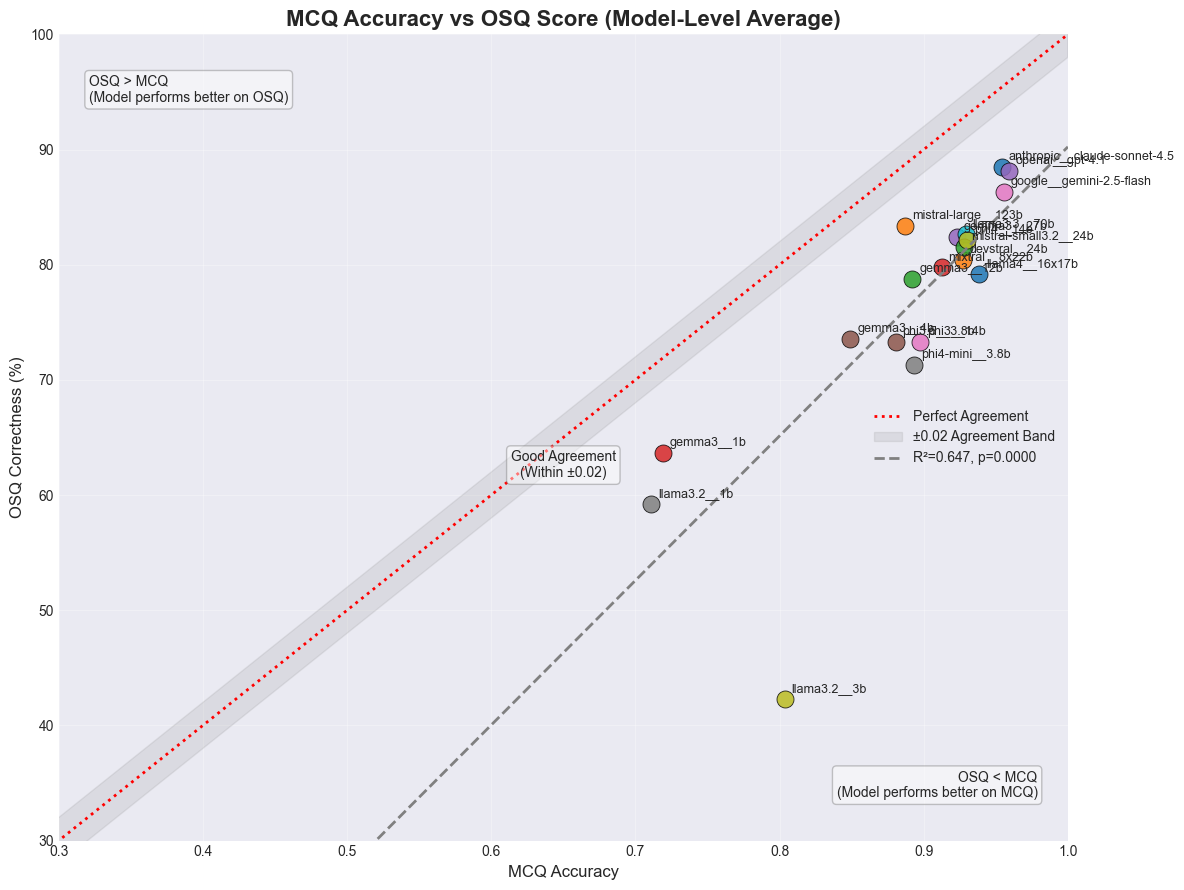

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# ======================================================
# DATA
# ======================================================

df = aligned_df_intersection

# ======================================================
# MODEL-LEVEL AGGREGATION (AVG ACROSS ALL JUDGES)
# ======================================================

mcq_by_model = (
    df.groupby('model')['mcq_avg_correct'].mean()
)

osq_by_model = (
    df.groupby('model')['osq_percentage'].mean()
)

comparison_df = (
    mcq_by_model
    .rename("mcq_accuracy")
    .to_frame()
    .join(osq_by_model.rename("osq_score"))
)

# Normalized OSQ ONLY for agreement logic
comparison_df["osq_norm"] = comparison_df["osq_score"] / 100.0
comparison_df["agreement_diff"] = (
    comparison_df["osq_norm"] - comparison_df["mcq_accuracy"]
)

# ======================================================
# PARAMETRIC CONFIGURATION
# ======================================================

tolerance = 0.02
label_box_alpha = 0.45
label_fontsize = 10

# ======================================================
# REGION CLASSIFICATION
# ======================================================

def classify_region(diff, tol):
    if diff > tol:
        return "OSQ > MCQ"
    elif diff < -tol:
        return "OSQ < MCQ"
    else:
        return "Good Agreement"

comparison_df["region"] = comparison_df["agreement_diff"].apply(
    lambda d: classify_region(d, tolerance)
)

# ======================================================
# REGRESSION (MODEL-LEVEL)
# ======================================================

x = comparison_df["mcq_accuracy"].values
y = comparison_df["osq_score"].values

slope, intercept, r_value, p_value, _ = linregress(x, y)

# ======================================================
# PLOT
# ======================================================

fig, ax = plt.subplots(figsize=(12, 9))

palette = sns.color_palette("tab10", len(comparison_df))

# -------------------------------
# Scatter points
# -------------------------------

for (model, row), color in zip(comparison_df.iterrows(), palette):
    ax.scatter(
        row["mcq_accuracy"],
        row["osq_score"],
        s=150,
        color=color,
        edgecolors="black",
        linewidths=0.6,
        alpha=0.85
    )
    ax.annotate(
        model,
        (row["mcq_accuracy"], row["osq_score"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# -------------------------------
# Lines
# -------------------------------

x_line = np.linspace(0, 1, 400)

# Perfect agreement
ax.plot(
    x_line,
    100 * x_line,
    color="red",
    linestyle=":",
    linewidth=2,
    label="Perfect Agreement"
)

# Agreement band
ax.fill_between(
    x_line,
    100 * (x_line - tolerance),
    100 * (x_line + tolerance),
    color="gray",
    alpha=0.15,
    label=f"±{tolerance:.02f} Agreement Band"
)

# Regression
ax.plot(
    x_line,
    slope * x_line + intercept,
    linestyle="--",
    color="gray",
    linewidth=2,
    label=f"R²={r_value**2:.3f}, p={p_value:.4f}"
)

# ======================================================
# AXIS LIMITS (CHANGE THESE FREELY)
# ======================================================

ax.set_xlim(0.3, 1.0)
ax.set_ylim(30, 100)

# ======================================================
# DYNAMIC REGION LABELS (ZOOM-SAFE)
# ======================================================

# Pull actual visible limits AFTER setting them
x_lo, x_hi = ax.get_xlim()
y_lo, y_hi = ax.get_ylim()

x_range = x_hi - x_lo
y_range = y_hi - y_lo

# Midpoint along perfect-agreement line
x_mid = x_lo + 0.5 * x_range
y_mid = 100 * x_mid

# Offset agreement label slightly below band
agreement_y = y_mid - tolerance * 100 * 1.2

# OSQ > MCQ (top-left)
ax.text(
    x_lo + 0.03 * x_range,
    y_hi - 0.05 * y_range,
    "OSQ > MCQ\n(Model performs better on OSQ)",
    ha="left", va="top",
    fontsize=label_fontsize,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white", ec="gray",
        alpha=label_box_alpha
    )
)

# Good Agreement (centered on diagonal)
ax.text(
    x_mid,
    agreement_y,
    f"Good Agreement\n(Within ±{tolerance:.02f})",
    ha="center", va="center",
    fontsize=label_fontsize,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white", ec="gray",
        alpha=label_box_alpha
    )
)

# OSQ < MCQ (bottom-right)
ax.text(
    x_hi - 0.03 * x_range,
    y_lo + 0.05 * y_range,
    "OSQ < MCQ\n(Model performs better on MCQ)",
    ha="right", va="bottom",
    fontsize=label_fontsize,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white", ec="gray",
        alpha=label_box_alpha
    )
)

# ======================================================
# FINAL STYLING
# ======================================================

ax.set_xlabel("MCQ Accuracy", fontsize=12)
ax.set_ylabel("OSQ Correctness (%)", fontsize=12)
ax.set_title(
    "MCQ Accuracy vs OSQ Score (Model-Level Average)",
    fontsize=16,
    fontweight="bold"
)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    output_dir / "mcq_vs_osq_scatter_regions_model_avg.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### 4.3 Correlation Analysis (Pearson & Spearman)

In [56]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

print('\n📊 Correlation Analysis (Pearson & Spearman)\n')

df = aligned_df_intersection

correlation_results = []

# --------------------------------------------------
# MCQ accuracy (avg across judges, per model)
# --------------------------------------------------

mcq_by_model = (
    df
    .groupby('model')['mcq_avg_correct']
    .mean()
)

# --------------------------------------------------
# Per-judge correlations
# --------------------------------------------------

judges = df['judge_model'].unique()

for judge in judges:
    df_j = df[df['judge_model'] == judge]

    # OSQ per model for this judge
    osq_by_model_j = (
        df_j
        .groupby('model')['osq_percentage']
        .mean()
    )

    comparison = pd.DataFrame({
        'mcq': mcq_by_model,
        'osq': osq_by_model_j
    }).dropna()

    if len(comparison) > 1:
        pearson_r, pearson_p = pearsonr(
            comparison['mcq'],
            comparison['osq']
        )
        spearman_r, spearman_p = spearmanr(
            comparison['mcq'],
            comparison['osq']
        )

        correlation_results.append({
            'judge': judge,
            'pearson_r': pearson_r,
            'pearson_p': pearson_p,
            'spearman_r': spearman_r,
            'spearman_p': spearman_p,
            'n': len(comparison)
        })

# --------------------------------------------------
# Average across all judges
# --------------------------------------------------

osq_avg_by_model = (
    df
    .groupby('model')['osq_percentage']
    .mean()
)

avg_comparison = pd.DataFrame({
    'mcq': mcq_by_model,
    'osq': osq_avg_by_model
}).dropna()

if len(avg_comparison) > 1:
    pearson_r_avg, pearson_p_avg = pearsonr(
        avg_comparison['mcq'],
        avg_comparison['osq']
    )
    spearman_r_avg, spearman_p_avg = spearmanr(
        avg_comparison['mcq'],
        avg_comparison['osq']
    )

    correlation_results.append({
        'judge': 'Average',
        'pearson_r': pearson_r_avg,
        'pearson_p': pearson_p_avg,
        'spearman_r': spearman_r_avg,
        'spearman_p': spearman_p_avg,
        'n': len(avg_comparison)
    })

# --------------------------------------------------
# Results table
# --------------------------------------------------

corr_results_df = pd.DataFrame(correlation_results)

print('Correlation Results:')
print(corr_results_df.to_string(index=False))

# --------------------------------------------------
# Export
# --------------------------------------------------

corr_results_df.to_csv(
    output_dir / 'table_mcq_osq_correlations.csv',
    index=False
)

export_latex_table(
    corr_results_df,
    'table_mcq_osq_correlations.tex',
    'MCQ vs OSQ Correlation Analysis',
    'tab:mcq_osq_corr'
)



📊 Correlation Analysis (Pearson & Spearman)

Correlation Results:
            judge  pearson_r  pearson_p  spearman_r  spearman_p  n
     gpt-oss_120b   0.797552   0.000043    0.800000    0.000039 19
openai_gpt-5-mini   0.810574   0.000026    0.814035    0.000022 19
          Average   0.804475   0.000033    0.807018    0.000030 19
   ✓ Exported: table_mcq_osq_correlations.tex


### 4.4 Wilcoxon Signed-Rank Test

In [58]:
from scipy.stats import wilcoxon
import pandas as pd

print('\n📊 Wilcoxon Signed-Rank Test\n')

df = aligned_df_intersection

wilcoxon_results = []

# --------------------------------------------------
# MCQ accuracy (avg across judges, per model)
# --------------------------------------------------

mcq_by_model = (
    df
    .groupby('model')['mcq_avg_correct']
    .mean()
)

# --------------------------------------------------
# Per-judge Wilcoxon tests
# --------------------------------------------------

judges = df['judge_model'].unique()

for judge in judges:
    df_j = df[df['judge_model'] == judge]

    # OSQ per model for this judge (normalized to 0–1)
    osq_by_model_j = (
        df_j
        .groupby('model')['osq_percentage']
        .mean()
        / 100.0
    )

    comparison = pd.DataFrame({
        'mcq': mcq_by_model,
        'osq': osq_by_model_j
    }).dropna()

    if len(comparison) > 1:
        differences = comparison['mcq'] - comparison['osq']

        stat, p_value = wilcoxon(
            differences,
            alternative='two-sided'
        )

        wilcoxon_results.append({
            'judge': judge,
            'stat': stat,
            'p_value': p_value,
            'median_diff': differences.median(),
            'mean_diff': differences.mean(),
            'n': len(comparison)
        })

# --------------------------------------------------
# Average across all judges
# --------------------------------------------------

osq_avg_by_model = (
    df
    .groupby('model')['osq_percentage']
    .mean()
    / 100.0
)

avg_comparison = pd.DataFrame({
    'mcq': mcq_by_model,
    'osq': osq_avg_by_model
}).dropna()

if len(avg_comparison) > 1:
    differences = avg_comparison['mcq'] - avg_comparison['osq']

    stat, p_value = wilcoxon(
        differences,
        alternative='two-sided'
    )

    wilcoxon_results.append({
        'judge': 'Average',
        'stat': stat,
        'p_value': p_value,
        'median_diff': differences.median(),
        'mean_diff': differences.mean(),
        'n': len(avg_comparison)
    })

# --------------------------------------------------
# Results table
# --------------------------------------------------

wilcoxon_df = pd.DataFrame(wilcoxon_results)

print('Wilcoxon Test Results:')
print(wilcoxon_df.to_string(index=False))

# --------------------------------------------------
# Export
# --------------------------------------------------

wilcoxon_df.to_csv(
    output_dir / 'table_wilcoxon_results.csv',
    index=False
)

export_latex_table(
    wilcoxon_df,
    'table_wilcoxon_results.tex',
    'Wilcoxon Signed-Rank Test Results',
    'tab:wilcoxon'
)



📊 Wilcoxon Signed-Rank Test

Wilcoxon Test Results:
            judge  stat  p_value  median_diff  mean_diff  n
     gpt-oss_120b   0.0 0.000004     0.143763   0.160212 19
openai_gpt-5-mini   0.0 0.000004     0.076000   0.091734 19
          Average   0.0 0.000004     0.112503   0.125970 19
   ✓ Exported: table_wilcoxon_results.tex


### 4.5 Effect Size (Cohen's d for Paired Samples)

In [60]:
import pandas as pd
import numpy as np

print('\n📊 Effect Size (Cohen\'s d)\n')

df = aligned_df_intersection

# --------------------------------------------------
# Helper: Cohen's d for paired samples
# --------------------------------------------------

def cohens_d_paired(differences):
    """Cohen's d for paired samples"""
    std = differences.std(ddof=1)
    if std == 0 or np.isnan(std):
        return np.nan
    return differences.mean() / std

# --------------------------------------------------
# MCQ accuracy (avg across judges, per model)
# --------------------------------------------------

mcq_by_model = (
    df
    .groupby('model')['mcq_avg_correct']
    .mean()
)

effect_sizes = []

# --------------------------------------------------
# Per-judge effect sizes
# --------------------------------------------------

judges = df['judge_model'].unique()

for judge in judges:
    df_j = df[df['judge_model'] == judge]

    # OSQ per model for this judge (normalized to 0–1)
    osq_by_model_j = (
        df_j
        .groupby('model')['osq_percentage']
        .mean()
        / 100.0
    )

    comparison = pd.DataFrame({
        'mcq': mcq_by_model,
        'osq': osq_by_model_j
    }).dropna()

    if len(comparison) > 1:
        differences = comparison['mcq'] - comparison['osq']
        cohens_d = cohens_d_paired(differences)

        if np.isnan(cohens_d):
            interp = 'Undefined'
        elif abs(cohens_d) < 0.20:
            interp = 'Negligible'
        elif abs(cohens_d) < 0.50:
            interp = 'Small'
        elif abs(cohens_d) < 0.80:
            interp = 'Medium'
        else:
            interp = 'Large'

        effect_sizes.append({
            'judge': judge,
            'cohens_d': cohens_d,
            'interpretation': interp,
            'n': len(comparison)
        })

# --------------------------------------------------
# Average across all judges
# --------------------------------------------------

osq_avg_by_model = (
    df
    .groupby('model')['osq_percentage']
    .mean()
    / 100.0
)

avg_comparison = pd.DataFrame({
    'mcq': mcq_by_model,
    'osq': osq_avg_by_model
}).dropna()

if len(avg_comparison) > 1:
    differences = avg_comparison['mcq'] - avg_comparison['osq']
    cohens_d = cohens_d_paired(differences)

    if np.isnan(cohens_d):
        interp = 'Undefined'
    elif abs(cohens_d) < 0.20:
        interp = 'Negligible'
    elif abs(cohens_d) < 0.50:
        interp = 'Small'
    elif abs(cohens_d) < 0.80:
        interp = 'Medium'
    else:
        interp = 'Large'

    effect_sizes.append({
        'judge': 'Average',
        'cohens_d': cohens_d,
        'interpretation': interp,
        'n': len(avg_comparison)
    })

# --------------------------------------------------
# Results table
# --------------------------------------------------

effect_size_df = pd.DataFrame(effect_sizes)

print('Effect Sizes (Cohen\'s d):')
print(effect_size_df.to_string(index=False))

# --------------------------------------------------
# Export
# --------------------------------------------------

effect_size_df.to_csv(
    output_dir / 'table_effect_sizes.csv',
    index=False
)

export_latex_table(
    effect_size_df,
    'table_effect_sizes.tex',
    'Effect Sizes for Format Comparison',
    'tab:effect_sizes'
)



📊 Effect Size (Cohen's d)

Effect Sizes (Cohen's d):
            judge  cohens_d interpretation  n
     gpt-oss_120b  2.347714          Large 19
openai_gpt-5-mini  1.298741          Large 19
          Average  1.816562          Large 19
   ✓ Exported: table_effect_sizes.tex


### 4.6 Per-Model Differences

In [61]:
import pandas as pd

print('\n📊 Per-Model Differences (Δᵢ = MCQ - OSQ)\n')

df = aligned_df_intersection

# --------------------------------------------------
# Model-level averages across all judges
# --------------------------------------------------

mcq_by_model = (
    df
    .groupby('model')['mcq_avg_correct']
    .mean()
)

osq_by_model = (
    df
    .groupby('model')['osq_percentage']
    .mean()
    / 100.0   # normalize OSQ to 0–1 to match MCQ
)

# --------------------------------------------------
# Per-model delta computation
# --------------------------------------------------

per_model_diff = (
    pd.DataFrame({
        'mcq_accuracy': mcq_by_model,
        'osq_mean': osq_by_model
    })
    .dropna()
    .assign(delta_i=lambda d: d['mcq_accuracy'] - d['osq_mean'])
    .reset_index()
    .rename(columns={'index': 'model'})
    .sort_values('delta_i', ascending=False)
)

# --------------------------------------------------
# Output
# --------------------------------------------------

print('Per-Model Differences (first 10):')
print(per_model_diff.head(10).to_string(index=False))

# --------------------------------------------------
# Export
# --------------------------------------------------

per_model_diff.to_csv(
    output_dir / 'table_per_model_differences.csv',
    index=False
)

export_latex_table(
    per_model_diff,
    'table_per_model_differences.tex',
    'Per-Model Format Differences',
    'tab:model_diff'
)



📊 Per-Model Differences (Δᵢ = MCQ - OSQ)

Per-Model Differences (first 10):
                model  mcq_accuracy  osq_mean  delta_i
         llama3.2__3b      0.803550  0.422959 0.380592
      phi4-mini__3.8b      0.893491  0.712669 0.180822
            phi3__14b      0.897633  0.732580 0.165053
         phi3.5__3.8b      0.880473  0.733284 0.147189
       llama4__16x17b      0.938462  0.792012 0.146450
        devstral__24b      0.927219  0.804077 0.123142
         llama3.2__1b      0.710947  0.591982 0.118964
       mixtral__8x22b      0.912426  0.797562 0.114864
           gemma3__4b      0.849112  0.735379 0.113734
mistral-small3.2__24b      0.927811  0.815308 0.112503
   ✓ Exported: table_per_model_differences.tex


### 4.7 Format Comparison Interpretation

In [65]:
print('\n📋 Format Comparison Interpretation (Model-Level, Judge-Averaged)\n')

# --------------------------------------------------
# Extract average results
# --------------------------------------------------

avg_pearson = corr_results_df.loc[
    corr_results_df['judge'] == 'Average', 'pearson_r'
].values[0]

avg_spearman = corr_results_df.loc[
    corr_results_df['judge'] == 'Average', 'spearman_r'
].values[0]

avg_wilcoxon_p = wilcoxon_df.loc[
    wilcoxon_df['judge'] == 'Average', 'p_value'
].values[0]

avg_cohens_d = effect_size_df.loc[
    effect_size_df['judge'] == 'Average', 'cohens_d'
].values[0]

# --------------------------------------------------
# 1. Correlation interpretation (alignment)
# --------------------------------------------------

if avg_pearson >= 0.80 and avg_spearman >= 0.80:
    corr_interp = (
        "Strong alignment: models that perform well on MCQ also perform well on OSQ "
        "(rank-order equivalence)"
    )
elif avg_pearson >= 0.50 or avg_spearman >= 0.50:
    corr_interp = (
        "Moderate alignment: model rankings are partially consistent across formats"
    )
else:
    corr_interp = (
        "Weak alignment: MCQ and OSQ rankings differ substantially"
    )

# --------------------------------------------------
# 2. Wilcoxon interpretation (directional bias)
# --------------------------------------------------

if avg_wilcoxon_p >= 0.05:
    wilcox_interp = (
        "No statistically reliable directional bias detected between MCQ and OSQ scores"
    )
else:
    wilcox_interp = (
        "Statistically reliable directional bias detected: "
        "one format tends to score consistently higher across models"
    )

# --------------------------------------------------
# 3. Effect size interpretation (practical magnitude)
# --------------------------------------------------

abs_d = abs(avg_cohens_d)

if abs_d < 0.20:
    effect_interp = (
        "Negligible practical difference: observed score differences are very small "
        "relative to model-to-model variability"
    )
elif abs_d < 0.50:
    effect_interp = (
        "Small practical difference: formats differ slightly but are still broadly comparable"
    )
elif abs_d < 0.80:
    effect_interp = (
        "Medium practical difference: format choice meaningfully affects absolute scores"
    )
else:
    effect_interp = (
        "Large practical difference: MCQ and OSQ are not interchangeable in absolute scoring"
    )

# --------------------------------------------------
# Print detailed interpretation
# --------------------------------------------------

print(f'Pearson r:   {avg_pearson:.3f}')
print(f'Spearman ρ:  {avg_spearman:.3f}')
print(f'→ {corr_interp}')

print(f'\nWilcoxon p-value: {avg_wilcoxon_p:.4f}')
print(f'→ {wilcox_interp}')

print(f'\nCohen\'s d: {avg_cohens_d:.3f}')
print(f'→ {effect_interp}')

# --------------------------------------------------
# Overall synthesis
# --------------------------------------------------

if (
    avg_pearson >= 0.80 and
    avg_spearman >= 0.80 and
    avg_wilcoxon_p >= 0.05 and
    abs_d < 0.20
):
    final_interp = (
        "MCQ and OSQ formats are effectively equivalent at the model level: "
        "they produce aligned rankings with no meaningful or systematic score differences."
    )
elif abs_d >= 0.80:
    final_interp = (
        "MCQ and OSQ formats show strong rank-order alignment but differ substantially "
        "in absolute difficulty; the formats are not interchangeable without calibration."
    )
else:
    final_interp = (
        "MCQ and OSQ formats are partially overlapping: rankings are broadly aligned, "
        "but systematic and/or practically meaningful differences exist."
    )

print('\n✓ Final interpretation:')
print(final_interp)



📋 Format Comparison Interpretation (Model-Level, Judge-Averaged)

Pearson r:   0.804
Spearman ρ:  0.807
→ Strong alignment: models that perform well on MCQ also perform well on OSQ (rank-order equivalence)

Wilcoxon p-value: 0.0000
→ Statistically reliable directional bias detected: one format tends to score consistently higher across models

Cohen's d: 1.817
→ Large practical difference: MCQ and OSQ are not interchangeable in absolute scoring

✓ Final interpretation:
MCQ and OSQ formats show strong rank-order alignment but differ substantially in absolute difficulty; the formats are not interchangeable without calibration.


---
## 5. TOKENOMICS & COST-EFFECTIVENESS

Evaluate cost-quality trade-offs using token counts and pricing.

### Analyses:
1. **Token & Cost Metrics:** Calculate tokens and costs per response
2. **Efficiency Metrics:** Cost per score point, cost per 1000 questions
3. **Visual Diagnostic:** Cost-quality bubble chart
4. **Interpretation:** Identify cost-effective models

### 5.0 Structural Components

**Analytical Question**

We evaluate how models trade off quality and cost by quantifying token usage, monetary cost, and efficiency, and by identifying models that are Pareto-optimal in terms of cost-effectiveness.

**Threat to Validity**

Reporting accuracy or OSQ scores alone may favor models that are prohibitively expensive to deploy at scale. Without incorporating cost, conclusions about "best" models may be impractical for real-world use, especially in large-scale evaluation or operational settings.

**Evidence Requirements**

We require:
1. Token counts per response (prompt and completion) for each model.
2. Per-model cost estimates based on provider pricing.
3. At least one scalar efficiency metric linking cost or tokens to quality.
4. A way to identify models that are not dominated by cheaper or better alternatives.

### 5.1 Token Counting

In [66]:
print('\n📊 Token Counting\n')

def count_tokens(text, encoding='cl100k_base'):
    """Count tokens using tiktoken"""
    if pd.isna(text) or text == '':
        return 0
    try:
        enc = tiktoken.get_encoding(encoding)
        return len(enc.encode(str(text)))
    except:
        return 0

# Add token counts
print('Counting tokens...')
osq_filtered['prompt_tokens'] = osq_filtered['osq_prompt'].apply(count_tokens)
osq_filtered['response_tokens'] = osq_filtered['model_response'].apply(count_tokens)
osq_filtered['total_tokens'] = osq_filtered['prompt_tokens'] + osq_filtered['response_tokens']

print('Token Statistics:')
print(osq_filtered[['prompt_tokens', 'response_tokens', 'total_tokens']].describe())


📊 Token Counting

Counting tokens...
Token Statistics:
       prompt_tokens  response_tokens  total_tokens
count   32110.000000     32110.000000  32110.000000
mean       30.005917        58.347618     88.353535
std         8.490222        31.549686     32.233248
min        13.000000         2.000000     23.000000
25%        24.000000        42.000000     69.000000
50%        29.000000        61.000000     89.000000
75%        34.000000        76.000000    106.000000
max        75.000000       506.000000    554.000000


### 5.2 Cost Calculation (Model-Specific Pricing)

In [ ]:
print('\n📊 Cost Calculation\n')

# Model-specific pricing ($/1M tokens)
MODEL_PRICING = {
    'anthropic__claude-sonnet-4.5': {'input': 3.00, 'output': 15.00},
    'google__gemini-2.5-flash': {'input': 0.30, 'output': 2.50},
    'openai__gpt-4.1': {'input': 2.00, 'output': 8.00},
    'mistral-large__123b': {'input': 3.00, 'output': 9.00},
    'mistral-small3.2__24b': {'input': 0.06, 'output': 0.18},
    'llama3.2__1b': {'input': 0.02, 'output': 0.02},
    'llama3.2__3b': {'input': 0.018, 'output': 0.018},
    'llama3.3__70b': {'input': 0.10, 'output': 0.40},
    'llama4__16x17b': {'input': 0.22, 'output': 0.85},
    'mixtral__8x22b': {'input': 2.00, 'output': 6.00},
    'gemma3__1b': {'input': 0.01, 'output': 0.01},
    'gemma3__4b': {'input': 0.01703, 'output': 0.06815},
    'gemma3__12b': {'input': 0.03, 'output': 0.10},
    'gemma3__27b': {'input': 0.07, 'output': 0.50},
    'phi3.5__3.8b': {'input': 0.10, 'output': 0.10},
    'phi3__14b': {'input': 1.00, 'output': 1.00},
    'phi4-mini__3.8b': {'input': 0.05, 'output': 0.10},
    'phi4__14b': {'input': 0.07, 'output': 0.14},
    'devstral__24b': {'input': 0.10, 'output': 0.30},
}

def calculate_cost(row):
    """Calculate cost per response"""
    pricing = MODEL_PRICING.get(row['model'], {'input': 0, 'output': 0})
    input_cost = row['prompt_tokens'] * (pricing['input'] / 1_000_000)
    output_cost = row['response_tokens'] * (pricing['output'] / 1_000_000)
    return input_cost + output_cost

osq_filtered['cost_per_response'] = osq_filtered.apply(calculate_cost, axis=1)

print(f'Cost calculated for {len(osq_filtered)} responses')

### 5.3 Aggregate Tokenomics Metrics

In [ ]:
print('\n📊 Tokenomics Aggregation\n')

tokenomics = osq_filtered.groupby('model').agg({
    'prompt_tokens': 'mean',
    'response_tokens': 'mean',
    'total_tokens': 'mean',
    'cost_per_response': 'mean',
    'total_score': 'mean'
}).reset_index()

tokenomics['cost_per_1000'] = tokenomics['cost_per_response'] * 1000
tokenomics['cost_per_score'] = tokenomics['cost_per_response'] / (tokenomics['total_score'] / 100)

print('Tokenomics Summary (first 10):')
print(tokenomics.head(10).to_string(index=False))

# Export
tokenomics.to_csv(output_dir / 'table_tokenomics.csv', index=False)
export_latex_table(
    tokenomics[['model', 'response_tokens', 'cost_per_1000', 'total_score', 'cost_per_score']],
    'table_tokenomics.tex',
    'Tokenomics and Cost-Effectiveness Summary',
    'tab:tokenomics'
)

### 5.4 Visual: Cost-Quality Bubble Chart

In [ ]:
print('\n📊 PLOT 9: Cost-Quality Bubble Chart\n')

fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    tokenomics['cost_per_1000'],
    tokenomics['total_score'],
    s=tokenomics['response_tokens'] * 5,
    c=tokenomics['cost_per_score'],
    cmap='RdYlGn_r',
    alpha=0.6,
    edgecolors='black',
    linewidths=1.5
)

# Labels
for _, row in tokenomics.iterrows():
    ax.annotate(
        row['model'],
        (row['cost_per_1000'], row['total_score']),
        fontsize=8,
        ha='center'
    )

# Quadrants
median_cost = tokenomics['cost_per_1000'].median()
median_quality = tokenomics['total_score'].median()
ax.axvline(median_cost, color='gray', linestyle=':', alpha=0.5)
ax.axhline(median_quality, color='gray', linestyle=':', alpha=0.5)

# Quadrant labels
ax.text(ax.get_xlim()[0]*1.05, ax.get_ylim()[1]*0.98, 
        'High Quality\nLow Cost\n(Optimal)', 
        fontsize=10, ha='left', va='top', 
        color='green', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cost per Score Point ($)', fontsize=12)

ax.set_xlabel('Cost per 1,000 Questions ($)', fontsize=12)
ax.set_ylabel('Mean OSQ Score (0-100)', fontsize=12)
ax.set_title('Cost-Quality Trade-off\n(Bubble size = avg response tokens)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'fig_cost_quality_bubble.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✅ Saved: {output_dir}/fig_cost_quality_bubble.png')

### 5.5 Tokenomics Interpretation

In [ ]:
print('\n📋 Tokenomics Interpretation\n')

# Best efficiency
best_efficiency = tokenomics.nsmallest(3, 'cost_per_score')[['model', 'cost_per_score', 'total_score']]
print('Most Cost-Efficient Models:')
print(best_efficiency.to_string(index=False))

# Best quality
best_quality = tokenomics.nlargest(3, 'total_score')[['model', 'total_score', 'cost_per_1000']]
print('\nHighest Quality Models:')
print(best_quality.to_string(index=False))

# Budget tiers
tokenomics['tier'] = pd.cut(
    tokenomics['cost_per_1000'],
    bins=[0, 10, 50, np.inf],
    labels=['Budget', 'Mid-tier', 'Premium']
)

print('\nModels by Cost Tier:')
print(tokenomics.groupby('tier')['model'].apply(list))

---
## 6. SUMMARY & EXPORT

Comprehensive summary of all analyses and export manifest.

### 6.1 Analysis Summary

In [ ]:
print('\n' + '='*80)
print('ANALYSIS SUMMARY')
print('='*80)

print('\n1. MCQ POSITION BIAS ANALYSIS')
print(f'   Models analyzed: {len(chi_square_df)}')
print(f'   Significant chi-square (p<0.05): {(chi_square_df["p_value"] < 0.05).sum()}')
print(f'   Mean Cramér\'s V: {chi_square_df["cramers_v"].mean():.4f}')
print(f'   Significant Friedman (p<0.05): {(friedman_df["p_value"] < 0.05).sum()}')

print('\n2. OSQ-SPECIFIC ANALYSIS')
print(f'   Models analyzed: {len(osq_stats_model)}')
print(f'   Judges: {len(COMPLETE_JUDGES)}')
print(f'   Mean OSQ score: {osq_filtered["total_score"].mean():.2f}')
if 'corr_df' in locals() and len(corr_df) > 0:
    print(f'   Avg inter-judge correlation: {corr_df["spearman_rho"].mean():.3f}')

print('\n3. FORMAT COMPARISON')
print(f'   Matched questions: {len(matched_question_ids)}')
print(f'   Pearson correlation (avg): {avg_pearson:.3f}')
print(f'   Spearman correlation (avg): {avg_spearman:.3f}')
print(f'   Cohen\'s d (avg): {avg_cohens_d:.3f}')

print('\n4. TOKENOMICS')
print(f'   Models analyzed: {len(tokenomics)}')
print(f'   Mean cost per 1000 questions: ${tokenomics["cost_per_1000"].mean():.2f}')
print(f'   Mean cost per score point: ${tokenomics["cost_per_score"].mean():.6f}')

print('\n' + '='*80)

### 6.2 Export Manifest

In [ ]:
import os

print('\n📁 EXPORT MANIFEST')
print('='*80)

# List all output files
output_files = sorted(output_dir.glob('*'))

print('\nFIGURES:')
figs = [f for f in output_files if f.suffix == '.png']
for i, f in enumerate(figs, 1):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {i}. {f.name:50s} ({size_kb:8.1f} KB)')

print('\nTABLES (CSV):')
csvs = [f for f in output_files if f.suffix == '.csv']
for i, f in enumerate(csvs, 1):
    print(f'  {i}. {f.name}')

print('\nTABLES (LaTeX):')
texs = [f for f in output_files if f.suffix == '.tex']
for i, f in enumerate(texs, 1):
    print(f'  {i}. {f.name}')

print(f'\nTotal files: {len(output_files)}')
print('='*80)

### 6.3 Key Findings Summary

In [ ]:
findings = []

# Position bias
no_bias_models = interpretation_df[interpretation_df['category'] == 'No bias']['model'].tolist()
if len(no_bias_models) > 0:
    findings.append(f'Position Bias: {len(no_bias_models)} models show no position bias')
else:
    findings.append(f'Position Bias: All models show some degree of position bias')

# OSQ reliability
if 'avg_rho' in locals():
    if avg_rho >= 0.80:
        findings.append(f'OSQ Reliability: High (ρ={avg_rho:.3f})')
    elif avg_rho >= 0.50:
        findings.append(f'OSQ Reliability: Moderate (ρ={avg_rho:.3f})')
    else:
        findings.append(f'OSQ Reliability: Low (ρ={avg_rho:.3f})')

# Format comparison
findings.append(f'Format Alignment: {corr_interp} (r={avg_pearson:.3f})')

# Tokenomics
best_model = tokenomics.nsmallest(1, 'cost_per_score').iloc[0]
findings.append(f'Most Efficient: {best_model["model"]} (${best_model["cost_per_score"]:.6f}/point)')

print('\n📋 KEY FINDINGS')
print('='*80)
for i, finding in enumerate(findings, 1):
    print(f'{i}. {finding}')
print('='*80)

# Save to file
with open(output_dir / 'key_findings.txt', 'w') as f:
    f.write('KEY FINDINGS - Analysis v2\n')
    f.write('='*80 + '\n\n')
    for i, finding in enumerate(findings, 1):
        f.write(f'{i}. {finding}\n')

print(f'\n✅ Saved key findings to {output_dir}/key_findings.txt')